In [1]:
from pathlib import Path
from matplotlib import lines
import pandas as pd
import numpy as np
import re

# ===== 1. Paths =====
data_dir = Path("data")
out_dir = Path("tables")
out_dir.mkdir(exist_ok=True)

compTT_csv = data_dir / "compTT_comptt_sample_v2.csv"
compPS_csv = data_dir / "compPS_compps_sample_v2.csv"

compTT_tex = out_dir / "table_compTT_comptt_sample.tex"
compPS_tex = out_dir / "table_compPS_compps_sample.tex"


# ===== 2. Helper functions =====
def latex_escape(text):
    """Escape LaTeX special characters while preserving simple math fragments."""
    if pd.isna(text):
        return ""
    text = str(text)

    replacements = {
        "&": r"\&",
        "%": r"\%",
        "$": r"\$",
        "#": r"\#",
        "_": r"\_",
        "{": r"\{",
        "}": r"\}",
        "~": r"\textasciitilde{}",
        "^": r"\textasciicircum{}",
    }
    for k, v in replacements.items():
        text = text.replace(k, v)

    # Restore common LaTeX snippets if they were escaped from notes.
    text = text.replace(r"\textasciitilde{}", r"$\sim$")
    text = text.replace("+-", r"$\pm$")
    return text


def fmt_num(x, ndigits=3):
    """Format numeric values compactly, avoiding scientific notation for values like 0.009."""
    if pd.isna(x) or x == "":
        return ""

    try:
        x = float(x)
    except Exception:
        return latex_escape(x)

    if x == 0:
        return "0"

    # Only use scientific notation for extremely small or very large values.
    if abs(x) < 1e-4 or abs(x) >= 1e5:
        return f"{x:.2e}"

    # For small Eddington ratios such as 0.009, keep decimal notation.
    if abs(x) < 0.01:
        return f"{x:.4f}".rstrip("0").rstrip(".")

    if abs(x) < 0.1:
        return f"{x:.3f}".rstrip("0").rstrip(".")

    if abs(x) < 10:
        return f"{x:.3g}"

    if abs(x - round(x)) < 1e-8:
        return f"{x:.0f}"

    return f"{x:.3g}"


def find_col(df, candidates):
    """Find a column by trying several possible names."""
    normalized = {c.lower().replace(" ", "").replace("_", ""): c for c in df.columns}
    for name in candidates:
        key = name.lower().replace(" ", "").replace("_", "")
        if key in normalized:
            return normalized[key]
    raise KeyError(f"None of these columns were found: {candidates}\nAvailable columns: {list(df.columns)}")


def normalize_columns(df):
    """Map the current CSV column names to standard internal names, excluding Notes."""

    required_cols = [
        "Source",
        "Type",
        "Electron_Temperature_keV",
        "Optical_Depth_tau",
        "kTe_Lower_keV",
        "kTe_Upper_keV",
        "tau_Lower",
        "tau_Upper",
        "Eddington_Ratio",
    ]

    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise KeyError(
            "Missing columns: "
            + ", ".join(missing)
            + "\nAvailable columns: "
            + ", ".join(df.columns)
        )

    out = df.rename(
        columns={
            "Source": "source",
            "Type": "type",
            "Electron_Temperature_keV": "kTe",
            "Optical_Depth_tau": "tau",
            "kTe_Lower_keV": "kTe_low",
            "kTe_Upper_keV": "kTe_high",
            "tau_Lower": "tau_low",
            "tau_Upper": "tau_high",
            "Eddington_Ratio": "lambda_Edd",
        }
    )

    return out[
        [
            "source",
            "type",
            "kTe",
            "kTe_low",
            "kTe_high",
            "tau",
            "tau_low",
            "tau_high",
            "lambda_Edd",
        ]
    ]


def fmt_param(value, lower_bound, upper_bound, rtol=1e-3, atol=1e-6):
    """
    Format a parameter as:
    value^{+upper_error}_{-lower_error}
    or value \pm error if upper and lower errors are equal.

    The lower_bound and upper_bound columns are treated as absolute bounds,
    not as errors.
    """
    if pd.isna(value) or value == "":
        return ""

    try:
        val = float(value)
    except Exception:
        return latex_escape(value)

    if pd.isna(lower_bound) or pd.isna(upper_bound) or lower_bound == "" or upper_bound == "":
        return rf"${fmt_num(val)}$"

    low = float(lower_bound)
    high = float(upper_bound)

    err_low = val - low
    err_high = high - val

    # Avoid tiny negative values caused by rounding or CSV precision.
    if abs(err_low) < atol:
        err_low = 0.0
    if abs(err_high) < atol:
        err_high = 0.0

    if abs(err_low - err_high) <= max(atol, rtol * max(abs(err_low), abs(err_high), 1.0)):
        return rf"${fmt_num(val)} \pm {fmt_num(err_low)}$"

    return rf"${fmt_num(val)}^{{+{fmt_num(err_high)}}}_{{-{fmt_num(err_low)}}}$"


def make_table_star_tex(df, caption, label, note, output_path):
    """Create a two-column-width LaTeX table using table* + tabular."""
    df = normalize_columns(df)

    lines = []
    lines.append(r"\begin{table*}")
    lines.append(r"\centering")
    lines.append(rf"\caption{{{caption}}}")
    lines.append(rf"\label{{{label}}}")
    lines.append(r"\renewcommand{\arraystretch}{1.25}")
    lines.append(r"\begin{tabular}{llccc}")
    lines.append(r"\hline")
    lines.append(
        r"Source & Type & "
        r"$kT_{\rm e}$ (keV) & $\tau$ & "
        r"$\lambda_{\rm Edd}$ \\"
    )
    lines.append(r"\hline")

    for _, row in df.iterrows():
        vals = [
            latex_escape(row["source"]),
            latex_escape(row["type"]),
            fmt_param(row["kTe"], row["kTe_low"], row["kTe_high"]),
            fmt_param(row["tau"], row["tau_low"], row["tau_high"]),
            fmt_num(row["lambda_Edd"]),
        ]
        lines.append(" & ".join(vals) + r" \\")

    lines.append(r"\hline")
    lines.append(r"\end{tabular}")
    lines.append(r"\renewcommand{\arraystretch}{1.0}")

    if note:
        lines.append(rf"\begin{{minipage}}{{0.95\textwidth}}")
        lines.append(r"\footnotesize")
        lines.append(note)
        lines.append(r"\end{minipage}")

    lines.append(r"\end{table*}")

    output_path.write_text("\n".join(lines), encoding="utf-8")
    print(f"Wrote: {output_path}")


# ===== 3. Read CSVs and generate TeX tables =====
df_compTT = pd.read_csv(compTT_csv)
df_compPS = pd.read_csv(compPS_csv)

# Convert compTT/comptt slab half-depth to full slab optical depth.
for col in ["Optical_Depth_tau", "tau_Lower", "tau_Upper"]:
    df_compTT[col] = 2.0 * df_compTT[col]

make_table_star_tex(
    df_compTT,
    caption=r"Radio-quiet Seyfert sample fitted with slab \texttt{compTT}/\texttt{comptt}.",
    label="tab:comptt_sample",
    note=None,
    output_path=compTT_tex,
)

make_table_star_tex(
    df_compPS,
    caption=r"Radio-quiet Seyfert sample fitted with slab \texttt{compPS}/\texttt{compps}.",
    label="tab:compps_sample",
    note=None,
    output_path=compPS_tex,
)

Wrote: tables/table_compTT_comptt_sample.tex
Wrote: tables/table_compPS_compps_sample.tex


compTT main sample for y statistics: n = 13
definition                                      <y>      sigma_log_y
Bessel       $4\theta K_3/K_2\,\tau$        0.7696       0.0856
Rel.         $4\theta(1+4\theta)\tau$       0.8294       0.0914
Linear       $4\theta\tau$                  0.6489       0.0996
Rel.+depth   $4\theta(1+4\theta)\tau(1+\tau)$   3.4139       0.1819


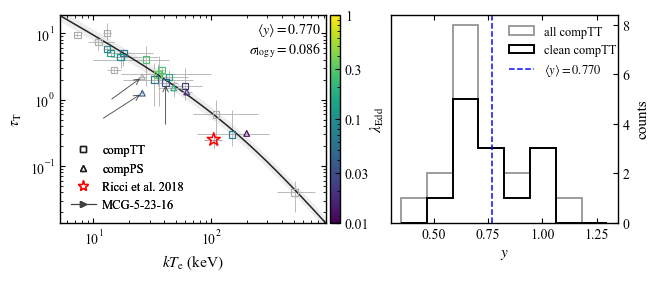

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D
from matplotlib.ticker import NullFormatter
from scipy.special import kve

from plot_style import apply_mnras_style, get_double_column_size

apply_mnras_style()
plt.rcParams["axes.grid"] = False
data_dir = Path("data")
compTT_csv = data_dir / "compTT_comptt_sample_v2.csv"
compPS_csv = data_dir / "compPS_compps_sample_v2.csv"
FIGURE_DIR = Path("figure")
FIGURE_DIR.mkdir(exist_ok=True)

# Read the two slab-corona samples.  For compTT, convert the reported slab
# half-depth to full slab optical depth, matching the table convention above.
compTT_plot = pd.read_csv(compTT_csv).assign(sample="compTT")
compPS_plot = pd.read_csv(compPS_csv).assign(sample="compPS")

numeric_cols = [
    "Electron_Temperature_keV", "Optical_Depth_tau",
    "kTe_Lower_keV", "kTe_Upper_keV", "tau_Lower", "tau_Upper",
    "Eddington_Ratio",
]
for frame in (compTT_plot, compPS_plot):
    frame[numeric_cols] = frame[numeric_cols].apply(pd.to_numeric, errors="coerce")

for col in ["Optical_Depth_tau", "tau_Lower", "tau_Upper"]:
    compTT_plot[col] *= 2.0

lambda_vmin, lambda_vmax = 0.01, 1.0
norm = LogNorm(vmin=lambda_vmin, vmax=lambda_vmax)
cmap = plt.get_cmap("viridis")
light_gray = "0.68"
edge_gray = "0.55"

compTT_plot["force_gray"] = compTT_plot["Source"].eq("NGC 5506")
compPS_plot["force_gray"] = (
    compPS_plot["Source"].eq("MCG-5-23-16")
    & np.isclose(compPS_plot["Eddington_Ratio"], 0.032)
)

for frame in (compTT_plot, compPS_plot):
    frame["in_lambda_range"] = frame["Eddington_Ratio"].between(
        lambda_vmin, lambda_vmax, inclusive="both"
    )
    frame["use_lambda_color"] = frame["in_lambda_range"] & ~frame["force_gray"]
    frame["is_mcg_5_23_16"] = frame["Source"].eq("MCG-5-23-16")


def row_color(row):
    if bool(row["use_lambda_color"]):
        return cmap(norm(row["Eddington_Ratio"]))
    return light_gray


def asymmetric_error(row, central, lower, upper):
    lo = row[central] - row[lower]
    hi = row[upper] - row[central]
    return np.array([[max(lo, 0.0)], [max(hi, 0.0)]], dtype=float)


fig, (ax, ax_hist) = plt.subplots(
    1,
    2,
    figsize=get_double_column_size(row_height_scale=.9),
    gridspec_kw={"width_ratios": [1.05, 0.75], "wspace": 0.05},
)


def draw_sample(frame, marker, markersize, label, zorder):
    for _, row in frame.iterrows():
        color = row_color(row)
        x = row["Electron_Temperature_keV"]
        y = row["Optical_Depth_tau"]
        ax.errorbar(
            [x],
            [y],
            xerr=asymmetric_error(row, "Electron_Temperature_keV", "kTe_Lower_keV", "kTe_Upper_keV"),
            yerr=asymmetric_error(row, "Optical_Depth_tau", "tau_Lower", "tau_Upper"),
            fmt="none",
            ecolor="0.68",
            elinewidth=0.65,
            capsize=0,
            alpha=0.9,
            zorder=zorder - 1,
        )
        ax.scatter(
            [x],
            [y],
            marker=marker,
            s=markersize**2,
            facecolors="none",
            edgecolors=[color],
            linewidths=0.85,
            alpha=0.98,
            zorder=zorder,
        )


draw_sample(compTT_plot, marker="s", markersize=4.7, label="compTT", zorder=4)
draw_sample(compPS_plot, marker="^", markersize=4.1, label="compPS", zorder=5)

# Point to all MCG-5-23-16 entries with arrows only.
annotation_offsets = {
    ("compTT", 0.032): (0, -30),
    ("compPS", 0.032): (-22, -16),
    ("compPS", 0.038): (-28, -18),
}
for _, row in pd.concat([compTT_plot, compPS_plot], ignore_index=True).query("is_mcg_5_23_16").iterrows():
    x = row["Electron_Temperature_keV"]
    y = row["Optical_Depth_tau"]
    dx, dy = annotation_offsets[(row["sample"], round(row["Eddington_Ratio"], 3))]
    ax.annotate(
        "",
        xy=(x, y),
        xytext=(dx, dy),
        textcoords="offset points",
        arrowprops={"arrowstyle": "->", "lw": 0.6, "color": "0.25", "shrinkA": 0, "shrinkB": 2},
        zorder=8,
    )

ricci_kte = 105.0
ricci_kte_err = 18.0
ricci_tau = 0.25
ricci_tau_err = 0.06
ax.errorbar(
    [ricci_kte], [ricci_tau],
    xerr=[[ricci_kte_err], [ricci_kte_err]],
    yerr=[[ricci_tau_err], [ricci_tau_err]],
    fmt="none",
    ecolor="0.68",
    elinewidth=0.8,
    capsize=0,
    zorder=8,
)
ax.scatter(
    [ricci_kte], [ricci_tau],
    marker="*",
    s=96,
    facecolors="none",
    edgecolors="red",
    linewidths=1.1,
    zorder=9,
)

# y statistics for the compTT main sample: color-coded compTT points excluding
# the MCG-5-23-16 special entry.
compTT_y_sample = compTT_plot.loc[
    compTT_plot["use_lambda_color"] & ~compTT_plot["is_mcg_5_23_16"]
].copy()

def theta_from_kte(kte_keV):
    return np.asarray(kte_keV, dtype=float) / 511.0


def bessel_factor(theta):
    x = 1.0 / np.asarray(theta, dtype=float)
    return 4.0 * theta * kve(3, x) / kve(2, x)


y_definitions = [
    ("Bessel", r"$4\theta K_3/K_2\,\tau$", lambda th, tau: bessel_factor(th) * tau,
     lambda th, y0: y0 / bessel_factor(th), "0.10", "-"),
    ("Rel.", r"$4\theta(1+4\theta)\tau$", lambda th, tau: 4.0 * th * (1.0 + 4.0 * th) * tau,
     lambda th, y0: y0 / (4.0 * th * (1.0 + 4.0 * th)), "#0072B2", "--"),
    ("Linear", r"$4\theta\tau$", lambda th, tau: 4.0 * th * tau,
     lambda th, y0: y0 / (4.0 * th), "#D55E00", ":"),
    ("Rel.+depth", r"$4\theta(1+4\theta)\tau(1+\tau)$", lambda th, tau: 4.0 * th * (1.0 + 4.0 * th) * tau * (1.0 + tau),
     lambda th, y0: (-1.0 + np.sqrt(1.0 + 4.0 * y0 / (4.0 * th * (1.0 + 4.0 * th)))) / 2.0,
     "#009E73", "-."),
]

x_values = np.concatenate([
    compTT_plot["kTe_Lower_keV"].to_numpy(),
    compTT_plot["kTe_Upper_keV"].to_numpy(),
    compPS_plot["kTe_Lower_keV"].to_numpy(),
    compPS_plot["kTe_Upper_keV"].to_numpy(),
    [ricci_kte - ricci_kte_err, ricci_kte + ricci_kte_err],
])
y_values = np.concatenate([
    compTT_plot["tau_Lower"].to_numpy(),
    compTT_plot["tau_Upper"].to_numpy(),
    compPS_plot["tau_Lower"].to_numpy(),
    compPS_plot["tau_Upper"].to_numpy(),
    [ricci_tau - ricci_tau_err, ricci_tau + ricci_tau_err],
])
x_values = x_values[np.isfinite(x_values) & (x_values > 0)]
y_values = y_values[np.isfinite(y_values) & (y_values > 0)]
xlim = (x_values.min() * 0.75, x_values.max() * 1.25)
ylim = (y_values.min() * 0.70, y_values.max() * 1.35)
x_curve = np.logspace(np.log10(xlim[0]), np.log10(xlim[1]), 500)
theta_curve = theta_from_kte(x_curve)

theta_main = theta_from_kte(compTT_y_sample["Electron_Temperature_keV"])
tau_main = compTT_y_sample["Optical_Depth_tau"].to_numpy(dtype=float)
theta_full_compTT = theta_from_kte(compTT_plot["Electron_Temperature_keV"])
tau_full_compTT = compTT_plot["Optical_Depth_tau"].to_numpy(dtype=float)
y_full_compTT = bessel_factor(theta_full_compTT) * tau_full_compTT
y_full_compTT = y_full_compTT[np.isfinite(y_full_compTT) & (y_full_compTT > 0)]
y_clean_compTT = np.array([], dtype=float)

print(f"compTT main sample for y statistics: n = {len(compTT_y_sample)}")
print("definition                                      <y>      sigma_log_y")
y_results = []
plotted_y_definition = "Bessel"
plotted_y_mean = np.nan
plotted_sigma_log_y = np.nan
for short_name, latex_label, y_func, tau_curve_func, color, linestyle in y_definitions:
    y_main = np.asarray(y_func(theta_main, tau_main), dtype=float)
    y_main = y_main[np.isfinite(y_main) & (y_main > 0)]
    y_mean = y_main.mean()
    sigma_log_y = np.std(np.log10(y_main) - np.log10(y_mean))
    y_results.append((short_name, y_mean, sigma_log_y))
    print(f"{short_name:12s} {latex_label:28s} {y_mean:8.4f} {sigma_log_y:12.4f}")

    if short_name != plotted_y_definition:
        continue

    plotted_y_mean = y_mean
    plotted_sigma_log_y = sigma_log_y
    y_clean_compTT = y_main.copy()
    tau_mean_curve = np.asarray(tau_curve_func(theta_curve, y_mean), dtype=float)
    tau_low_curve = np.asarray(tau_curve_func(theta_curve, y_mean * 10.0**(-sigma_log_y)), dtype=float)
    tau_high_curve = np.asarray(tau_curve_func(theta_curve, y_mean * 10.0**(sigma_log_y)), dtype=float)
    valid = (
        np.isfinite(tau_mean_curve) & np.isfinite(tau_low_curve) & np.isfinite(tau_high_curve)
        & (tau_mean_curve > 0) & (tau_low_curve > 0) & (tau_high_curve > 0)
    )
    lower_curve = np.minimum(tau_low_curve[valid], tau_high_curve[valid])
    upper_curve = np.maximum(tau_low_curve[valid], tau_high_curve[valid])
    ax.fill_between(
        x_curve[valid],
        lower_curve,
        upper_curve,
        color=color,
        alpha=0.08,
        linewidth=0,
        zorder=1,
    )
    ax.plot(
        x_curve[valid], tau_mean_curve[valid],
        color=color,
        linestyle=linestyle,
        linewidth=1.1,
        alpha=0.95,
        zorder=3,
    )

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_xlabel(r"$kT_{\rm e}$ (keV)")
ax.set_ylabel(r"$\tau_{\rm T}$")
ax.grid(False)

n_y_bins = 8
y_bins = np.linspace(0.35, 1.3, n_y_bins + 1)
ax_hist.hist(
    y_full_compTT,
    bins=y_bins,
    density=False,
    histtype="step",
    color="0.55",
    linewidth=1.2,
    label="all compTT",
)
ax_hist.hist(
    y_clean_compTT,
    bins=y_bins,
    density=False,
    histtype="step",
    color="black",
    linewidth=1.4,
    label="clean compTT",
)
ax_hist.axvline(
    plotted_y_mean,
    color="blue",
    linestyle="--",
    linewidth=1.1,
    alpha=0.95,
    label=fr"$\langle y\rangle={plotted_y_mean:.3f}$",
)
ax_hist.set_xlabel(r"$y$")
ax_hist.set_ylabel("counts")
ax_hist.yaxis.set_label_position("right")
ax_hist.yaxis.tick_right()
ax_hist.grid(False)
ax_hist.legend(frameon=False, loc="upper right", bbox_to_anchor=(1.045, 1.0))


sample_handles = [
    Line2D([], [], marker="s", linestyle="None", markersize=4.7, markerfacecolor="none", markeredgecolor="0.12", label="compTT"),
    Line2D([], [], marker="^", linestyle="None", markersize=4.1, markerfacecolor="none", markeredgecolor="0.12", label="compPS"),
    Line2D([], [], marker="*", linestyle="None", markersize=8.0, markerfacecolor="none", markeredgecolor="red", label="Ricci et al. 2018"),
    Line2D([], [], color="0.25", linewidth=0.8, marker=">", markersize=4.5, markevery=[1], label="MCG-5-23-16"),
]
sample_legend = ax.legend(handles=sample_handles, frameon=False, loc="lower left", handletextpad=0.5)
ax.add_artist(sample_legend)
ax.text(
    0.98,
    0.97,
    fr"$\langle y\rangle={plotted_y_mean:.3f}$" + "\n" + fr"$\sigma_{{\rm log\,y}}={plotted_sigma_log_y:.3f}$",
    transform=ax.transAxes,
    ha="right",
    va="top",
)

cbar = fig.colorbar(ScalarMappable(norm=norm, cmap=cmap), ax=ax, pad=0.01)
cbar.set_label(r"$\lambda_{\rm Edd}$", labelpad=0)
cbar.set_ticks([0.01, 0.03, 0.1, 0.3, 1.0])
cbar.set_ticklabels(["0.01", "0.03", "0.1", "0.3", "1"])

fig.savefig(FIGURE_DIR / "compTT_compPS_temperature_tau_eddington_y.pdf", dpi=300, bbox_inches="tight")
fig.savefig(FIGURE_DIR / "compTT_compPS_temperature_tau_eddington_y.png", dpi=300, bbox_inches="tight")
plt.show()

saved: figure/comppsc_actual_parameter_maps_xi100_log32x32.png
saved: figure/comppsc_actual_parameter_maps_xi100_log32x32.pdf


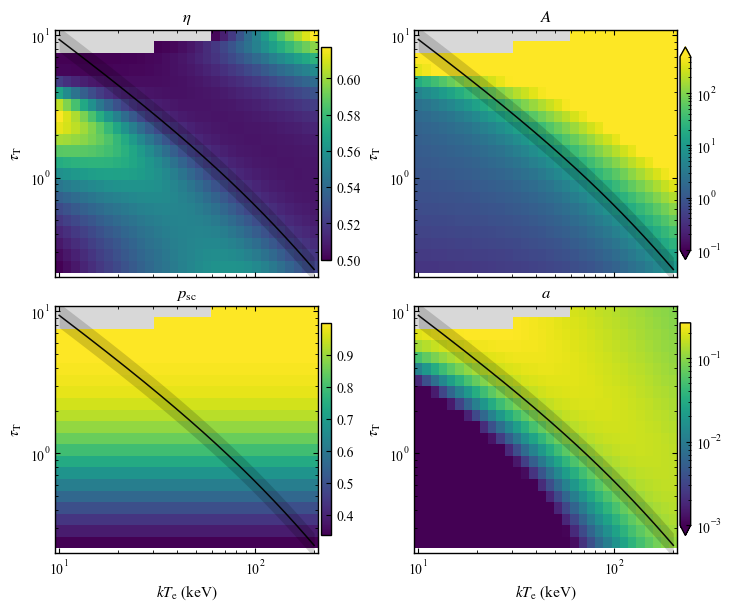

In [3]:
from pathlib import Path
import csv
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.special import kve

from plot_style import apply_mnras_style, get_double_column_size

apply_mnras_style()
plt.rcParams["axes.grid"] = False

fixed_xi = 100.0
grid_tag = "log32x32"
tau_min_plot = 0.2
common_cmap = "viridis"
y_ridge_band_alpha = 0.16

data_dir = Path("pair_balance/data")
figure_dir = Path("figure")
figure_dir.mkdir(exist_ok=True)


def column_suffix(value):
    return f"{float(value):g}".replace("-", "m").replace(".", "p")


def parse_kte_header(header):
    if "_kTe_" not in header:
        raise ValueError(f"Cannot parse kTe from header {header!r}")
    suffix = header.rsplit("_kTe_", maxsplit=1)[1]
    return float(suffix.replace("p", ".").replace("m", "-"))


def load_matrix_csv(path):
    with path.open(newline="") as handle:
        reader = csv.reader(handle)
        header = next(reader)
        kTe_values = np.array([parse_kte_header(cell) for cell in header[1:]], dtype=float)
        tau_values = []
        rows = []
        for row in reader:
            tau_values.append(float(row[0]))
            rows.append([float(cell) if cell else math.nan for cell in row[1:]])
    return np.array(tau_values, dtype=float), kTe_values, np.array(rows, dtype=float)


def restrict_tau_range(tau_values, values, tau_min):
    keep = tau_values >= float(tau_min)
    if not np.any(keep):
        raise ValueError(f"No tau grid points remain above tau_min={tau_min:g}")
    return tau_values[keep], values[keep, :]


def geometric_edges(values):
    centers = np.asarray(values, dtype=float)
    if centers.ndim != 1 or centers.size < 2:
        raise ValueError("geometric edges need at least two centers")
    if np.any(centers <= 0.0) or np.any(np.diff(centers) <= 0.0):
        raise ValueError("centers must be positive and strictly increasing")
    log_centers = np.log(centers)
    log_edges = np.empty(centers.size + 1, dtype=float)
    log_edges[1:-1] = 0.5 * (log_centers[:-1] + log_centers[1:])
    log_edges[0] = 2.0 * log_centers[0] - log_edges[1]
    log_edges[-1] = 2.0 * log_centers[-1] - log_edges[-2]
    return np.exp(log_edges)


def geometric_edges_with_lower_bound(values, lower_bound):
    edges = geometric_edges(values)
    edges[0] = max(edges[0], float(lower_bound))
    return edges


def bessel_factor(theta):
    theta = np.asarray(theta, dtype=float)
    x = 1.0 / theta
    return 4.0 * theta * kve(3, x) / kve(2, x)


def tau_curve_from_bessel_y(kTe_values, mean_y):
    return float(mean_y) / bessel_factor(np.asarray(kTe_values, dtype=float) / 511.0)


def tau_band_from_bessel_y(kTe_values, mean_y, sigma_log_y):
    lower = tau_curve_from_bessel_y(kTe_values, float(mean_y) * 10.0 ** (-float(sigma_log_y)))
    upper = tau_curve_from_bessel_y(kTe_values, float(mean_y) * 10.0 ** float(sigma_log_y))
    return np.minimum(lower, upper), np.maximum(lower, upper)


def compTT_main_y_statistics(path):
    frame = pd.read_csv(path)
    numeric_cols = ["Electron_Temperature_keV", "Optical_Depth_tau", "Eddington_Ratio"]
    frame[numeric_cols] = frame[numeric_cols].apply(pd.to_numeric, errors="coerce")
    frame["Optical_Depth_tau"] = 2.0 * frame["Optical_Depth_tau"]
    frame["force_gray"] = frame["Source"].eq("NGC 5506")
    frame["in_lambda_range"] = frame["Eddington_Ratio"].between(0.01, 1.0, inclusive="both")
    frame["use_lambda_color"] = frame["in_lambda_range"] & ~frame["force_gray"]
    frame["is_mcg_5_23_16"] = frame["Source"].eq("MCG-5-23-16")
    sample = frame.loc[frame["use_lambda_color"] & ~frame["is_mcg_5_23_16"]].copy()
    theta = sample["Electron_Temperature_keV"].to_numpy(dtype=float) / 511.0
    tau = sample["Optical_Depth_tau"].to_numpy(dtype=float)
    y_values = np.asarray(bessel_factor(theta) * tau, dtype=float)
    y_values = y_values[np.isfinite(y_values) & (y_values > 0.0)]
    mean_y = float(np.mean(y_values))
    sigma_log_y = float(np.std(np.log10(y_values) - np.log10(mean_y)))
    return mean_y, sigma_log_y, int(y_values.size)


slug = f"xi{column_suffix(fixed_xi)}_{grid_tag}"
paths = {
    "eta": data_dir / f"comppsc_actual_eta_{slug}_matrix.csv",
    "A_model": data_dir / f"comppsc_actual_A_model_{slug}_matrix.csv",
    "p_sc": data_dir / f"comppsc_actual_p_sc_{slug}_matrix.csv",
    "albedo": data_dir / f"comppsc_actual_albedo_ireflect_{slug}_matrix.csv",
}
valid_path = data_dir / f"comppsc_actual_valid_{slug}_matrix.csv"

valid_tau_all, kTe_values, valid_matrix_all = load_matrix_csv(valid_path)
tau_values, valid_matrix = restrict_tau_range(valid_tau_all, valid_matrix_all, tau_min_plot)
x_edges = geometric_edges(kTe_values)
y_edges = geometric_edges_with_lower_bound(tau_values, tau_min_plot)

mean_y, sigma_log_y, n_y = compTT_main_y_statistics(Path("data/compTT_comptt_sample_v2.csv"))
x_curve = np.logspace(np.log10(kTe_values[0]), np.log10(kTe_values[-1]), 500)
tau_y_curve = tau_curve_from_bessel_y(x_curve, mean_y)
tau_y_lower, tau_y_upper = tau_band_from_bessel_y(x_curve, mean_y, sigma_log_y)

plot_specs = [
    {
        "key": "eta",
        "title": r"$\eta$",
        "colorbar_label": r"$\eta$",
        "log_norm": False,
        "vmin": None,
        "vmax": None,
        "extend": "neither",
    },
    {
        "key": "A_model",
        "title": r"$A$",
        "colorbar_label": r"$A$",
        "log_norm": True,
        "vmin": 0.1,
        "vmax": 500.0,
        "extend": "both",
    },
    {
        "key": "p_sc",
        "title": r"$p_{\rm sc}$",
        "colorbar_label": r"$p_{\rm sc}$",
        "log_norm": False,
        "vmin": None,
        "vmax": None,
        "extend": "neither",
    },
    {
        "key": "albedo",
        "title": rf"$a$",
        "colorbar_label": r"$a$",
        "log_norm": True,
        "vmin": 1.0e-3,
        "vmax": None,
        "extend": "min",
    },
]

fig, axes = plt.subplots(
    2,
    2,
    figsize=get_double_column_size(row_height_scale=2.0),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)

for ax, spec in zip(axes.ravel(), plot_specs):
    matrix_tau_all, matrix_kTe, matrix_all = load_matrix_csv(paths[spec["key"]])
    matrix_tau, matrix = restrict_tau_range(matrix_tau_all, matrix_all, tau_min_plot)
    if not np.allclose(matrix_kTe, kTe_values) or not np.allclose(matrix_tau, tau_values):
        raise ValueError(f"Grid mismatch for {paths[spec['key']]}")

    values = np.where(valid_matrix >= 0.5, matrix, np.nan)
    positive = values[np.isfinite(values) & (values > 0.0)]
    cmap = plt.colormaps[common_cmap].copy()
    cmap.set_bad(color="#d8d8d8")

    norm = None
    if spec["log_norm"]:
        vmin = spec["vmin"] if spec["vmin"] is not None else float(np.min(positive))
        vmax = spec["vmax"] if spec["vmax"] is not None else float(np.max(positive))
        norm = LogNorm(vmin=float(vmin), vmax=float(vmax))
        cmap.set_under(cmap(0.0))
        cmap.set_over(cmap(1.0))

    mesh = ax.pcolormesh(
        x_edges,
        y_edges,
        np.ma.masked_invalid(values),
        shading="auto",
        cmap=cmap,
        norm=norm,
    )

    valid_band = (
        np.isfinite(tau_y_lower)
        & np.isfinite(tau_y_upper)
        & (tau_y_upper >= float(tau_min_plot))
        & (tau_y_lower > 0.0)
        & (tau_y_upper > 0.0)
    )
    ax.fill_between(
        x_curve[valid_band],
        np.maximum(tau_y_lower[valid_band], float(tau_min_plot)),
        tau_y_upper[valid_band],
        color="black",
        alpha=y_ridge_band_alpha,
        linewidth=0,
        zorder=7,
    )

    valid_curve = np.isfinite(tau_y_curve) & (tau_y_curve >= float(tau_min_plot))
    ax.plot(
        x_curve[valid_curve],
        tau_y_curve[valid_curve],
        color="black",
        linewidth=1.1,
        alpha=0.95,
        label=fr"$\langle y\rangle={mean_y:.3f}$",
        zorder=8,
    )

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title(spec["title"])
    ax.set_xlim(x_edges[0], x_edges[-1])
    ax.set_ylim(float(tau_min_plot), y_edges[-1])
    ax.grid(False)
    fig.colorbar(mesh, ax=ax, pad=0.01, shrink=0.86, extend=spec["extend"])

for ax in axes[-1, :]:
    ax.set_xlabel(r"$kT_{\rm e}$ (keV)")
for ax in axes[:, 0]:
    ax.set_ylabel(r"$\tau_{\rm T}$")
for ax in axes[:, 1]:
    ax.tick_params(axis="y", which="both", labelleft=True)
    ax.set_ylabel(r"$\tau_{\rm T}$")

png_path = figure_dir / f"comppsc_actual_parameter_maps_xi{column_suffix(fixed_xi)}_{grid_tag}.png"
pdf_path = figure_dir / f"comppsc_actual_parameter_maps_xi{column_suffix(fixed_xi)}_{grid_tag}.pdf"
fig.savefig(png_path, dpi=300, bbox_inches="tight")
fig.savefig(pdf_path, bbox_inches="tight")
print(f"saved: {png_path}")
print(f"saved: {pdf_path}")
plt.show()


saved: figure/fg_interpolated_equilibrium_curves.png
saved: figure/fg_interpolated_equilibrium_curves.pdf
saved: output/fg_interpolated_equilibrium_curves.csv
saved: output/fg_mcmc_posterior_samples.csv
saved: output/fg_mcmc_summary.csv
MCMC acceptance fraction: 0.890


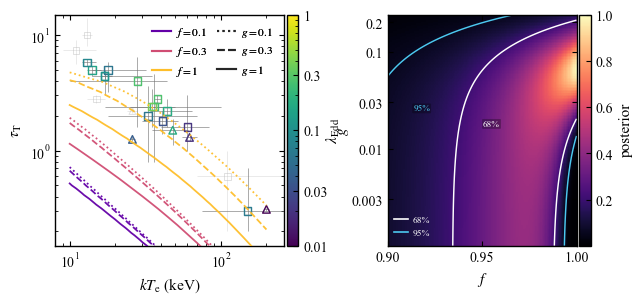

In [4]:
from pathlib import Path
import csv
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D
from matplotlib.ticker import NullFormatter, NullLocator
from scipy.interpolate import RegularGridInterpolator
from scipy.optimize import brentq

from plot_style import apply_mnras_style, get_double_column_size

apply_mnras_style()
plt.rcParams["axes.grid"] = False

fixed_xi = 100.0
grid_tag = "log32x32"
f_values = (0.1, 0.3, 1.0)
g_values = (0.1, 0.3, 1.0)
lambda_vmin, lambda_vmax = 0.01, 1.0

data_dir = Path("data")
grid_dir = Path("pair_balance/data")
figure_dir = Path("figure")
output_dir = Path("output")
figure_dir.mkdir(exist_ok=True)
output_dir.mkdir(exist_ok=True)


def column_suffix(value):
    return f"{float(value):g}".replace("-", "m").replace(".", "p")


def parse_kte_header(header):
    if "_kTe_" not in header:
        raise ValueError(f"Cannot parse kTe from header {header!r}")
    suffix = header.rsplit("_kTe_", maxsplit=1)[1]
    return float(suffix.replace("p", ".").replace("m", "-"))


def load_matrix_csv(path):
    with path.open(newline="") as handle:
        reader = csv.reader(handle)
        header = next(reader)
        kTe_values = np.array([parse_kte_header(cell) for cell in header[1:]], dtype=float)
        tau_values = []
        rows = []
        for row in reader:
            tau_values.append(float(row[0]))
            rows.append([float(cell) if cell else math.nan for cell in row[1:]])
    return np.array(tau_values, dtype=float), kTe_values, np.array(rows, dtype=float)


def matrix_path(quantity):
    slug = f"xi{column_suffix(fixed_xi)}_{grid_tag}"
    filenames = {
        "eta": f"comppsc_actual_eta_{slug}_matrix.csv",
        "A_model": f"comppsc_actual_A_model_{slug}_matrix.csv",
        "p_sc": f"comppsc_actual_p_sc_{slug}_matrix.csv",
        "albedo": f"comppsc_actual_albedo_ireflect_{slug}_matrix.csv",
    }
    return grid_dir / filenames[quantity]


def make_interpolator(quantity, *, log_values=False):
    tau_values, kTe_values, values = load_matrix_csv(matrix_path(quantity))
    if log_values:
        values = np.where(values > 0.0, np.log(values), np.nan)
    interp = RegularGridInterpolator(
        (np.log(kTe_values), np.log(tau_values)),
        values.T,
        bounds_error=False,
        fill_value=np.nan,
    )
    return interp, tau_values, kTe_values


eta_interp, tau_grid, kTe_grid = make_interpolator("eta")
psc_interp, _, _ = make_interpolator("p_sc")
A_interp, _, _ = make_interpolator("A_model", log_values=True)
albedo_interp, _, _ = make_interpolator("albedo", log_values=True)


def interp_values(interp, kTe_keV, tau_values, *, exp_value=False):
    tau_values = np.asarray(tau_values, dtype=float)
    points = np.column_stack([
        np.full(tau_values.size, math.log(float(kTe_keV))),
        np.log(tau_values),
    ])
    raw = np.asarray(interp(points), dtype=float)
    if exp_value:
        raw = np.exp(raw)
    return raw


def d_ratio_from_f(f_corona):
    if not 0.0 < f_corona <= 1.0:
        raise ValueError("f must satisfy 0 < f <= 1")
    return (1.0 - float(f_corona)) / float(f_corona)


def amplification_required_fg(eta, p_sc, albedo, f_corona, feedback_factor):
    d_ratio = d_ratio_from_f(f_corona)
    g_factor = float(feedback_factor)
    denominator = g_factor * (1.0 - albedo) * eta + d_ratio * (1.0 - g_factor * albedo * eta * p_sc)
    return (1.0 + d_ratio * p_sc) / np.maximum(denominator, 1.0e-30)


def energy_log_residual_grid(kTe_keV, tau_values, f_corona, feedback_factor):
    eta = interp_values(eta_interp, kTe_keV, tau_values)
    p_sc = interp_values(psc_interp, kTe_keV, tau_values)
    A_model = interp_values(A_interp, kTe_keV, tau_values, exp_value=True)
    albedo = interp_values(albedo_interp, kTe_keV, tau_values, exp_value=True)
    valid = (
        np.isfinite(eta) & (eta > 0.0)
        & np.isfinite(p_sc) & (p_sc > 0.0)
        & np.isfinite(A_model) & (A_model > 0.0)
        & np.isfinite(albedo) & (albedo > 0.0)
    )
    residuals = np.full_like(np.asarray(tau_values, dtype=float), np.nan, dtype=float)
    if np.any(valid):
        A_required = amplification_required_fg(
            eta[valid], p_sc[valid], albedo[valid], f_corona, feedback_factor
        )
        valid_required = np.isfinite(A_required) & (A_required > 0.0)
        residual_values = np.full(np.count_nonzero(valid), np.nan, dtype=float)
        residual_values[valid_required] = np.log(A_model[valid][valid_required] / A_required[valid_required])
        residuals[valid] = residual_values
    return residuals


def energy_log_residual_scalar(kTe_keV, tau_T, f_corona, feedback_factor):
    return float(energy_log_residual_grid(kTe_keV, np.array([tau_T]), f_corona, feedback_factor)[0])


def roots_at_kTe(kTe_keV, f_corona, feedback_factor):
    tau_scan = np.geomspace(float(tau_grid[0]), float(tau_grid[-1]), 520)
    residuals = energy_log_residual_grid(kTe_keV, tau_scan, f_corona, feedback_factor)
    roots = []
    for idx in range(tau_scan.size - 1):
        r0 = residuals[idx]
        r1 = residuals[idx + 1]
        if not (math.isfinite(r0) and math.isfinite(r1)):
            continue
        if abs(r0) < 1.0e-6:
            roots.append(float(tau_scan[idx]))
            continue
        if r0 * r1 > 0.0:
            continue
        log_lo = math.log(float(tau_scan[idx]))
        log_hi = math.log(float(tau_scan[idx + 1]))

        def residual_in_log_tau(log_tau):
            return energy_log_residual_scalar(kTe_keV, math.exp(log_tau), f_corona, feedback_factor)

        try:
            roots.append(math.exp(brentq(residual_in_log_tau, log_lo, log_hi, xtol=1.0e-5, rtol=1.0e-5)))
        except ValueError:
            continue
    deduped = []
    for root in roots:
        if not deduped or abs(math.log(root / deduped[-1])) > 1.0e-3:
            deduped.append(root)
    return deduped


def solve_interpolated_curve(f_corona, feedback_factor):
    kTe_curve = np.geomspace(float(kTe_grid[0]), float(kTe_grid[-1]), 180)
    tau_curve = []
    previous_tau = None
    for kTe_keV in kTe_curve:
        roots = roots_at_kTe(float(kTe_keV), f_corona, feedback_factor)
        if not roots:
            tau_curve.append(math.nan)
            continue
        if previous_tau is None or not math.isfinite(previous_tau):
            tau_root = max(roots)
        else:
            tau_root = min(roots, key=lambda value: abs(math.log(value / previous_tau)))
        tau_curve.append(tau_root)
        previous_tau = tau_root
    return kTe_curve, np.array(tau_curve, dtype=float)


curve_rows = []
curves = {}
for f_corona in f_values:
    for feedback_factor in g_values:
        kTe_curve, tau_curve = solve_interpolated_curve(f_corona, feedback_factor)
        curves[(f_corona, feedback_factor)] = (kTe_curve, tau_curve)
        for kTe_keV, tau_T in zip(kTe_curve, tau_curve):
            if math.isfinite(float(tau_T)):
                curve_rows.append({
                    "f_corona": f_corona,
                    "g_feedback": feedback_factor,
                    "kTe_keV": float(kTe_keV),
                    "tau_T": float(tau_T),
                })
curves_csv = output_dir / "fg_interpolated_equilibrium_curves.csv"
pd.DataFrame(curve_rows).to_csv(curves_csv, index=False)


def load_observation_points():
    compTT = pd.read_csv(data_dir / "compTT_comptt_sample_v2.csv").assign(sample="compTT")
    compPS = pd.read_csv(data_dir / "compPS_compps_sample_v2.csv").assign(sample="compPS")
    numeric_cols = [
        "Electron_Temperature_keV", "Optical_Depth_tau",
        "kTe_Lower_keV", "kTe_Upper_keV", "tau_Lower", "tau_Upper",
        "Eddington_Ratio",
    ]
    for frame in (compTT, compPS):
        frame[numeric_cols] = frame[numeric_cols].apply(pd.to_numeric, errors="coerce")
    for col in ["Optical_Depth_tau", "tau_Lower", "tau_Upper"]:
        compTT[col] *= 2.0
    compTT["force_gray"] = compTT["Source"].eq("NGC 5506")
    compPS["force_gray"] = compPS["Source"].eq("MCG-5-23-16") & np.isclose(compPS["Eddington_Ratio"], 0.032)
    points = pd.concat([compTT, compPS], ignore_index=True)
    points = points[
        points["Electron_Temperature_keV"].gt(0.0)
        & points["Optical_Depth_tau"].gt(0.0)
        & points["kTe_Lower_keV"].gt(0.0)
        & points["tau_Lower"].gt(0.0)
    ].copy()
    points["in_lambda_range"] = points["Eddington_Ratio"].between(lambda_vmin, lambda_vmax, inclusive="both")
    points["use_lambda_color"] = points["in_lambda_range"] & ~points["force_gray"]
    return points


all_points = load_observation_points()
clean_points = all_points[all_points["use_lambda_color"]].copy()
clean_compTT_points = clean_points[clean_points["sample"].eq("compTT")].copy()


def point_errors(frame):
    xerr = np.vstack([
        frame["Electron_Temperature_keV"].to_numpy() - frame["kTe_Lower_keV"].to_numpy(),
        frame["kTe_Upper_keV"].to_numpy() - frame["Electron_Temperature_keV"].to_numpy(),
    ])
    yerr = np.vstack([
        frame["Optical_Depth_tau"].to_numpy() - frame["tau_Lower"].to_numpy(),
        frame["tau_Upper"].to_numpy() - frame["Optical_Depth_tau"].to_numpy(),
    ])
    return np.clip(xerr, 0.0, np.inf), np.clip(yerr, 0.0, np.inf)


def energy_log_residual_points(kTe_values, tau_values, f_corona, feedback_factor):
    kTe_values = np.asarray(kTe_values, dtype=float)
    tau_values = np.asarray(tau_values, dtype=float)
    points = np.column_stack([np.log(kTe_values), np.log(tau_values)])
    eta = np.asarray(eta_interp(points), dtype=float)
    p_sc = np.asarray(psc_interp(points), dtype=float)
    A_model = np.exp(np.asarray(A_interp(points), dtype=float))
    albedo = np.exp(np.asarray(albedo_interp(points), dtype=float))
    valid = (
        np.isfinite(eta) & (eta > 0.0)
        & np.isfinite(p_sc) & (p_sc > 0.0)
        & np.isfinite(A_model) & (A_model > 0.0)
        & np.isfinite(albedo) & (albedo > 0.0)
    )
    residuals = np.full(kTe_values.shape, np.nan, dtype=float)
    if np.any(valid):
        A_required = amplification_required_fg(
            eta[valid], p_sc[valid], albedo[valid], f_corona, feedback_factor
        )
        good = np.isfinite(A_required) & (A_required > 0.0)
        values = np.full(np.count_nonzero(valid), np.nan, dtype=float)
        values[good] = np.log(A_model[valid][good] / A_required[good])
        residuals[valid] = values
    return residuals


mcmc_frame = clean_compTT_points.copy()
mcmc_valid = (
    np.isfinite(mcmc_frame["Electron_Temperature_keV"]) & np.isfinite(mcmc_frame["Optical_Depth_tau"])
    & np.isfinite(mcmc_frame["kTe_Lower_keV"]) & np.isfinite(mcmc_frame["kTe_Upper_keV"])
    & np.isfinite(mcmc_frame["tau_Lower"]) & np.isfinite(mcmc_frame["tau_Upper"])
    & (mcmc_frame["Electron_Temperature_keV"] >= float(kTe_grid[0]))
    & (mcmc_frame["Electron_Temperature_keV"] <= float(kTe_grid[-1]))
    & mcmc_frame["Electron_Temperature_keV"].gt(0.0)
    & mcmc_frame["Optical_Depth_tau"].gt(0.0)
    & mcmc_frame["kTe_Lower_keV"].gt(0.0)
    & mcmc_frame["kTe_Upper_keV"].gt(0.0)
    & mcmc_frame["tau_Lower"].gt(0.0)
    & mcmc_frame["tau_Upper"].gt(0.0)
)
mcmc_frame = mcmc_frame[mcmc_valid].copy()
mcmc_kTe = mcmc_frame["Electron_Temperature_keV"].to_numpy(dtype=float)
mcmc_tau = mcmc_frame["Optical_Depth_tau"].to_numpy(dtype=float)

f_bounds = (0.9, 1.0)
g_bounds = (0.001, 0.24)
finite_difference_step = 1.0e-3
intrinsic_log_scatter = 0.25


def log_observation_errors(frame):
    sigma_log_kTe_minus = np.log(frame["Electron_Temperature_keV"].to_numpy(dtype=float) / frame["kTe_Lower_keV"].to_numpy(dtype=float))
    sigma_log_kTe_plus = np.log(frame["kTe_Upper_keV"].to_numpy(dtype=float) / frame["Electron_Temperature_keV"].to_numpy(dtype=float))
    sigma_log_tau_minus = np.log(frame["Optical_Depth_tau"].to_numpy(dtype=float) / frame["tau_Lower"].to_numpy(dtype=float))
    sigma_log_tau_plus = np.log(frame["tau_Upper"].to_numpy(dtype=float) / frame["Optical_Depth_tau"].to_numpy(dtype=float))
    sigma_log_kTe = 0.5 * (np.clip(sigma_log_kTe_minus, 0.0, np.inf) + np.clip(sigma_log_kTe_plus, 0.0, np.inf))
    sigma_log_tau = 0.5 * (np.clip(sigma_log_tau_minus, 0.0, np.inf) + np.clip(sigma_log_tau_plus, 0.0, np.inf))
    return np.maximum(sigma_log_kTe, 1.0e-3), np.maximum(sigma_log_tau, 1.0e-3)


mcmc_sigma_log_kTe, mcmc_sigma_log_tau = log_observation_errors(mcmc_frame)
mcmc_sigma_eff_log_kTe = np.sqrt(mcmc_sigma_log_kTe**2 + intrinsic_log_scatter**2)
mcmc_sigma_eff_log_tau = np.sqrt(mcmc_sigma_log_tau**2 + intrinsic_log_scatter**2)



def transfer_terms_points(kTe_values, tau_values):
    kTe_values = np.asarray(kTe_values, dtype=float)
    tau_values = np.asarray(tau_values, dtype=float)
    points = np.column_stack([np.log(kTe_values), np.log(tau_values)])
    eta = np.asarray(eta_interp(points), dtype=float)
    p_sc = np.asarray(psc_interp(points), dtype=float)
    log_A_model = np.asarray(A_interp(points), dtype=float)
    albedo = np.exp(np.asarray(albedo_interp(points), dtype=float))
    valid = (
        np.isfinite(eta) & (eta > 0.0)
        & np.isfinite(p_sc) & (p_sc > 0.0)
        & np.isfinite(log_A_model)
        & np.isfinite(albedo) & (albedo > 0.0)
    )
    return {
        "eta": eta,
        "p_sc": p_sc,
        "log_A_model": log_A_model,
        "albedo": albedo,
        "valid": valid,
    }


mcmc_transfer_terms = {
    "center": transfer_terms_points(mcmc_kTe, mcmc_tau),
    "x_plus": transfer_terms_points(mcmc_kTe * math.exp(finite_difference_step), mcmc_tau),
    "x_minus": transfer_terms_points(mcmc_kTe * math.exp(-finite_difference_step), mcmc_tau),
    "y_plus": transfer_terms_points(mcmc_kTe, mcmc_tau * math.exp(finite_difference_step)),
    "y_minus": transfer_terms_points(mcmc_kTe, mcmc_tau * math.exp(-finite_difference_step)),
}


def energy_log_residual_from_terms(terms, f_corona, feedback_factor):
    residuals = np.full(terms["eta"].shape, np.nan, dtype=float)
    valid = terms["valid"]
    if np.any(valid):
        A_required = amplification_required_fg(
            terms["eta"][valid],
            terms["p_sc"][valid],
            terms["albedo"][valid],
            f_corona,
            feedback_factor,
        )
        good = np.isfinite(A_required) & (A_required > 0.0)
        values = np.full(np.count_nonzero(valid), np.nan, dtype=float)
        values[good] = terms["log_A_model"][valid][good] - np.log(A_required[good])
        residuals[valid] = values
    return residuals


def residual_and_gradient_fg(f_corona, feedback_factor):
    residual = energy_log_residual_from_terms(mcmc_transfer_terms["center"], f_corona, feedback_factor)
    residual_x_plus = energy_log_residual_from_terms(mcmc_transfer_terms["x_plus"], f_corona, feedback_factor)
    residual_x_minus = energy_log_residual_from_terms(mcmc_transfer_terms["x_minus"], f_corona, feedback_factor)
    residual_y_plus = energy_log_residual_from_terms(mcmc_transfer_terms["y_plus"], f_corona, feedback_factor)
    residual_y_minus = energy_log_residual_from_terms(mcmc_transfer_terms["y_minus"], f_corona, feedback_factor)
    dR_dlog_kTe = (residual_x_plus - residual_x_minus) / (2.0 * finite_difference_step)
    dR_dlog_tau = (residual_y_plus - residual_y_minus) / (2.0 * finite_difference_step)
    return residual, dR_dlog_kTe, dR_dlog_tau


def gaussian_curve_objective(residual, dR_dlog_kTe, dR_dlog_tau, sigma_log_kTe, sigma_log_tau, scatter):
    sigma_eff_log_kTe = np.sqrt(np.asarray(sigma_log_kTe, dtype=float)**2 + float(scatter)**2)
    sigma_eff_log_tau = np.sqrt(np.asarray(sigma_log_tau, dtype=float)**2 + float(scatter)**2)
    sigma_R2 = (dR_dlog_kTe * sigma_eff_log_kTe)**2 + (dR_dlog_tau * sigma_eff_log_tau)**2
    valid = np.isfinite(residual) & np.isfinite(sigma_R2) & (sigma_R2 > 0.0)
    if np.count_nonzero(valid) != residual.size:
        return math.inf
    return float(np.sum(residual[valid]**2 / sigma_R2[valid] + np.log(sigma_R2[valid])))


def curve_distance_objective_fg(f_corona, feedback_factor):
    residual, dR_dlog_kTe, dR_dlog_tau = residual_and_gradient_fg(f_corona, feedback_factor)
    return gaussian_curve_objective(
        residual,
        dR_dlog_kTe,
        dR_dlog_tau,
        mcmc_sigma_log_kTe,
        mcmc_sigma_log_tau,
        intrinsic_log_scatter,
    )


def log_prior_fg(f_g):
    f_corona, feedback_factor = np.asarray(f_g, dtype=float)
    if not (f_bounds[0] <= f_corona <= f_bounds[1]):
        return -math.inf
    if not (g_bounds[0] <= feedback_factor <= g_bounds[1]):
        return -math.inf
    return 0.0


def log_posterior_fg(f_g):
    log_prior = log_prior_fg(f_g)
    if not math.isfinite(log_prior):
        return -math.inf, -math.inf, log_prior, math.inf
    f_corona, feedback_factor = np.asarray(f_g, dtype=float)
    objective_value = curve_distance_objective_fg(float(f_corona), float(feedback_factor))
    if not math.isfinite(objective_value):
        return -math.inf, -math.inf, log_prior, math.inf
    log_likelihood = -0.5 * objective_value
    return float(log_likelihood + log_prior), float(log_likelihood), float(log_prior), float(objective_value)


def run_fg_mcmc(n_chains=64, n_steps=1400, burn_in=500, proposal_scale=(0.0025, 0.012), seed=20260623):
    rng = np.random.default_rng(seed)
    proposal_scale = np.asarray(proposal_scale, dtype=float)
    positions = np.column_stack([
        rng.uniform(f_bounds[0], f_bounds[1], size=n_chains),
        rng.uniform(g_bounds[0], g_bounds[1], size=n_chains),
    ])
    evaluated = [log_posterior_fg(position) for position in positions]
    log_prob = np.array([item[0] for item in evaluated], dtype=float)
    log_likelihood = np.array([item[1] for item in evaluated], dtype=float)
    log_prior = np.array([item[2] for item in evaluated], dtype=float)
    objective_value = np.array([item[3] for item in evaluated], dtype=float)
    accepted = np.zeros(n_chains, dtype=int)
    samples = []
    sample_log_prob = []
    sample_log_likelihood = []
    sample_log_prior = []
    sample_objective = []
    for step in range(n_steps):
        proposals = positions + rng.normal(0.0, proposal_scale, size=positions.shape)
        evaluated_proposals = [log_posterior_fg(proposal) for proposal in proposals]
        proposal_log_prob = np.array([item[0] for item in evaluated_proposals], dtype=float)
        proposal_log_likelihood = np.array([item[1] for item in evaluated_proposals], dtype=float)
        proposal_log_prior = np.array([item[2] for item in evaluated_proposals], dtype=float)
        proposal_objective = np.array([item[3] for item in evaluated_proposals], dtype=float)
        accept = np.log(rng.random(n_chains)) < (proposal_log_prob - log_prob)
        positions[accept] = proposals[accept]
        log_prob[accept] = proposal_log_prob[accept]
        log_likelihood[accept] = proposal_log_likelihood[accept]
        log_prior[accept] = proposal_log_prior[accept]
        objective_value[accept] = proposal_objective[accept]
        accepted += accept.astype(int)
        if step >= burn_in:
            samples.append(positions.copy())
            sample_log_prob.append(log_prob.copy())
            sample_log_likelihood.append(log_likelihood.copy())
            sample_log_prior.append(log_prior.copy())
            sample_objective.append(objective_value.copy())
    samples = np.vstack(samples)
    posterior = pd.DataFrame({
        "f_corona": samples[:, 0],
        "g_feedback": samples[:, 1],
        "log_likelihood": np.concatenate(sample_log_likelihood),
        "log_prior": np.concatenate(sample_log_prior),
        "log_posterior": np.concatenate(sample_log_prob),
        "objective": np.concatenate(sample_objective),
    })
    return posterior, float(np.mean(accepted / n_steps))



posterior_samples, mcmc_acceptance = run_fg_mcmc()
posterior_csv = output_dir / "fg_mcmc_posterior_samples.csv"
posterior_samples.to_csv(posterior_csv, index=False)

summary_rows = []
for column in ["f_corona", "g_feedback"]:
    q16, q50, q84 = posterior_samples[column].quantile([0.16, 0.50, 0.84]).to_numpy()
    summary_rows.append({
        "parameter": column,
        "q16": q16,
        "median": q50,
        "q84": q84,
        "acceptance_fraction": mcmc_acceptance,
        "n_clean_compTT": int(mcmc_kTe.size),
        "likelihood": "local_curve_distance_gaussian_with_log_sigma",
        "intrinsic_log_scatter": intrinsic_log_scatter,
    })
summary_csv = output_dir / "fg_mcmc_summary.csv"
pd.DataFrame(summary_rows).to_csv(summary_csv, index=False)

fig, (ax, ax_fg) = plt.subplots(
    1,
    2,
    figsize=get_double_column_size(row_height_scale=1.0),
    gridspec_kw={"width_ratios": [1.15, 0.95], "wspace": 0.24},
)
lambda_norm = LogNorm(vmin=lambda_vmin, vmax=lambda_vmax)
lambda_cmap = plt.get_cmap("viridis")
marker_map = {"compTT": "s", "compPS": "^"}

for sample, sub in all_points.groupby("sample", sort=False):
    xerr, yerr = point_errors(sub)
    ax.errorbar(
        sub["Electron_Temperature_keV"],
        sub["Optical_Depth_tau"],
        xerr=xerr,
        yerr=yerr,
        fmt="none",
        ecolor="0.72",
        elinewidth=0.6,
        alpha=0.35,
        capsize=0,
        zorder=1,
    )
    ax.scatter(
        sub["Electron_Temperature_keV"],
        sub["Optical_Depth_tau"],
        marker=marker_map.get(sample, "o"),
        facecolors="none",
        edgecolors="0.72",
        s=24,
        linewidths=0.72,
        alpha=0.42,
        zorder=2,
    )

for sample, sub in clean_points.groupby("sample", sort=False):
    xerr, yerr = point_errors(sub)
    colors = lambda_cmap(lambda_norm(sub["Eddington_Ratio"].to_numpy()))
    ax.errorbar(
        sub["Electron_Temperature_keV"],
        sub["Optical_Depth_tau"],
        xerr=xerr,
        yerr=yerr,
        fmt="none",
        ecolor="0.45",
        elinewidth=0.68,
        alpha=0.55,
        capsize=0,
        zorder=3,
    )
    ax.scatter(
        sub["Electron_Temperature_keV"],
        sub["Optical_Depth_tau"],
        marker=marker_map.get(sample, "o"),
        facecolors="none",
        edgecolors=colors,
        s=30,
        linewidths=1.0,
        alpha=0.98,
        zorder=4,
    )

f_colors = dict(zip(f_values, plt.get_cmap("plasma")(np.linspace(0.18, 0.86, len(f_values)))))
g_linestyles = {0.1: ":", 0.3: "--", 1.0: "-"}
for f_corona in f_values:
    for feedback_factor in g_values:
        kTe_curve, tau_curve = curves[(f_corona, feedback_factor)]
        valid = np.isfinite(tau_curve)
        if not np.any(valid):
            continue
        ax.plot(
            kTe_curve[valid],
            tau_curve[valid],
            color=f_colors[f_corona],
            linestyle=g_linestyles[feedback_factor],
            linewidth=1.28,
            alpha=0.95,
            zorder=5,
        )

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(8.0, 260.0)
ax.set_ylim(0.15, 15.0)
ax.set_xlabel(r"$kT_{\rm e}$ (keV)")
ax.set_ylabel(r"$\tau_{\rm T}$")
ax.grid(False)

f_handles = [Line2D([], [], color=f_colors[f_corona], lw=1.5, label=rf"$f={f_corona:g}$") for f_corona in f_values]
g_handles = [Line2D([], [], color="0.15", lw=1.5, linestyle=g_linestyles[g], label=rf"$g={g:g}$") for g in g_values]
legend2 = ax.legend(handles=f_handles + g_handles, frameon=False, loc="upper right", ncol=2, handlelength=1.7, fontsize=8.2, columnspacing=0.8, handletextpad=0.45)
ax.add_artist(legend2)

cbar = fig.colorbar(ScalarMappable(norm=lambda_norm, cmap=lambda_cmap), ax=ax, pad=0.012)
cbar.set_label(r"$\lambda_{\rm Edd}$", labelpad=-2)
cbar.set_ticks([0.01, 0.03, 0.1, 0.3, 1.0])
cbar.set_ticklabels(["0.01", "0.03", "0.1", "0.3", "1"])

def grid_widths(axis, *, log_axis=False):
    axis = np.asarray(axis, dtype=float)
    if log_axis:
        log_axis_values = np.log(axis)
        log_edges = np.empty(axis.size + 1, dtype=float)
        log_edges[1:-1] = 0.5 * (log_axis_values[:-1] + log_axis_values[1:])
        log_edges[0] = log_axis_values[0] - 0.5 * (log_axis_values[1] - log_axis_values[0])
        log_edges[-1] = log_axis_values[-1] + 0.5 * (log_axis_values[-1] - log_axis_values[-2])
        edges = np.exp(log_edges)
    else:
        edges = np.empty(axis.size + 1, dtype=float)
        edges[1:-1] = 0.5 * (axis[:-1] + axis[1:])
        edges[0] = axis[0] - 0.5 * (axis[1] - axis[0])
        edges[-1] = axis[-1] + 0.5 * (axis[-1] - axis[-2])
    return np.diff(edges)


def credible_density_thresholds(density, credible_masses, *, weights=None):
    values = np.asarray(density, dtype=float)
    if weights is None:
        weights = np.ones_like(values, dtype=float)
    else:
        weights = np.asarray(weights, dtype=float)
    values, weights = np.broadcast_arrays(values, weights)
    valid = np.isfinite(values) & (values > 0.0) & np.isfinite(weights) & (weights > 0.0)
    if not np.any(valid):
        return []
    values = values[valid]
    weights = weights[valid]
    order = np.argsort(values)[::-1]
    sorted_values = values[order]
    sorted_mass = sorted_values * weights[order]
    cumulative = np.cumsum(sorted_mass)
    cumulative /= cumulative[-1]
    thresholds = []
    for mass in credible_masses:
        index = int(np.searchsorted(cumulative, mass, side="left"))
        index = min(index, sorted_values.size - 1)
        thresholds.append({"mass": float(mass), "level": float(sorted_values[index])})
    return thresholds


f_axis = np.linspace(f_bounds[0], f_bounds[1], 150)
g_axis = np.geomspace(g_bounds[0], g_bounds[1], 150)
f_widths = grid_widths(f_axis)
g_widths = grid_widths(g_axis, log_axis=True)
posterior_cell_weights = g_widths[:, None] * f_widths[None, :]
f_mesh, g_mesh = np.meshgrid(f_axis, g_axis)
logp_grid = np.empty(f_mesh.size, dtype=float)

for i, (f_val, g_val) in enumerate(zip(f_mesh.ravel(), g_mesh.ravel())):
    logp_grid[i] = log_posterior_fg((f_val, g_val))[0]

logp_grid = logp_grid.reshape(f_mesh.shape)

posterior_density = np.exp(logp_grid - np.nanmax(logp_grid))
posterior_density = posterior_density / np.nanmax(posterior_density)
mesh = ax_fg.pcolormesh(
    f_mesh,
    g_mesh,
    np.ma.masked_invalid(posterior_density),
    shading="auto",
    cmap="magma",
)
credible_contours = credible_density_thresholds(posterior_density, (0.95, 0.68), weights=posterior_cell_weights)
contour_color_by_mass = {0.95: "#4cc9f0", 0.68: "#ffffff"}
valid_contours = [
    (item["mass"], item["level"], contour_color_by_mass[item["mass"]])
    for item in credible_contours
    if np.nanmin(posterior_density) < item["level"] < np.nanmax(posterior_density)
]
valid_contours = sorted(valid_contours, key=lambda item: item[1])
if valid_contours:
    contour_levels = [item[1] for item in valid_contours]
    contour_colors = [item[2] for item in valid_contours]
    contour_set = ax_fg.contour(
        f_mesh,
        g_mesh,
        posterior_density,
        levels=contour_levels,
        colors=contour_colors,
        linewidths=1.05,
    )
    contour_label_map = {level: f"{int(round(100.0 * mass))}%" for mass, level, _ in valid_contours}
    manual_label_positions_by_mass = {
        0.95: (0.918, 0.026),
        0.68: (0.955, 0.018),
    }
    for mass, level, color in valid_contours:
        label_x, label_y = manual_label_positions_by_mass[mass]
        ax_fg.text(
            label_x,
            label_y,
            contour_label_map[level],
            color=color,
            fontsize=6.6,
            ha="center",
            va="center",
            bbox={"boxstyle": "round,pad=0.10", "facecolor": "black", "edgecolor": "none", "alpha": 0.28},
        )
    contour_handles = [
        Line2D([], [], color=color, lw=1.2, label=f"{int(round(100.0 * mass))}%")
        for mass, _, color in sorted(valid_contours, key=lambda item: item[0])
    ]
    contour_legend = ax_fg.legend(
        handles=contour_handles,
        frameon=False,
        loc="lower left",
        bbox_to_anchor=(0.015, 0.02),
        fontsize=6.8,
        handlelength=1.5,
        handletextpad=0.45,
        borderaxespad=0.0,
    )
    for text in contour_legend.get_texts():
        text.set_color("white")

ax_fg.set_xscale("linear")
ax_fg.set_yscale("log")
ax_fg.set_xlim(*f_bounds)
ax_fg.set_ylim(*g_bounds)
ax_fg.set_xticks([0.90, 0.95, 1.00])
ax_fg.set_xticklabels(["0.90", "0.95", "1.00"])
g_major_ticks = [0.003, 0.01, 0.03, 0.1, 0.2]
ax_fg.set_yticks(g_major_ticks)
ax_fg.set_yticklabels(["0.003", "0.01", "0.03", "0.1", "0.2"])
ax_fg.yaxis.set_minor_locator(NullLocator())
ax_fg.yaxis.set_minor_formatter(NullFormatter())
ax_fg.set_xlabel(r"$f$")
ax_fg.set_ylabel(r"$g$", labelpad=0)
ax_fg.grid(False)
posterior_cbar = fig.colorbar(mesh, ax=ax_fg, pad=0.012)
posterior_cbar.set_label("posterior")

png_path = figure_dir / "fg_interpolated_equilibrium_curves.png"
pdf_path = figure_dir / "fg_interpolated_equilibrium_curves.pdf"
fig.savefig(png_path, dpi=300, bbox_inches="tight")
fig.savefig(pdf_path, bbox_inches="tight")
print(f"saved: {png_path}")
print(f"saved: {pdf_path}")
print(f"saved: {curves_csv}")
print(f"saved: {posterior_csv}")
print(f"saved: {summary_csv}")
print(f"MCMC acceptance fraction: {mcmc_acceptance:.3f}")
plt.show()


saved: figure/fg_intrinsic_scatter_sensitivity.png
saved: figure/fg_intrinsic_scatter_sensitivity.pdf
saved: output/fg_intrinsic_scatter_sensitivity_summary.csv
saved: output/fg_intrinsic_scatter_sensitivity_density.csv


,intrinsic_log_scatter,parameter,q16,median,q84,n_clean_compTT,method
0,0.0,f_corona,0.984354,0.992102,0.997726,14,deterministic_posterior_grid_with_log_sigma
1,0.0,g_feedback,0.010318,0.026050,0.041754,14,deterministic_posterior_grid_with_log_sigma
2,0.1,f_corona,0.974155,0.988311,0.996709,14,deterministic_posterior_grid_with_log_sigma
3,0.1,g_feedback,0.014560,0.037782,0.069258,14,deterministic_posterior_grid_with_log_sigma
4,0.5,f_corona,0.925780,0.964688,0.990520,14,deterministic_posterior_grid_with_log_sigma
5,0.5,g_feedback,0.039654,0.109847,0.192047,14,deterministic_posterior_grid_with_log_sigma


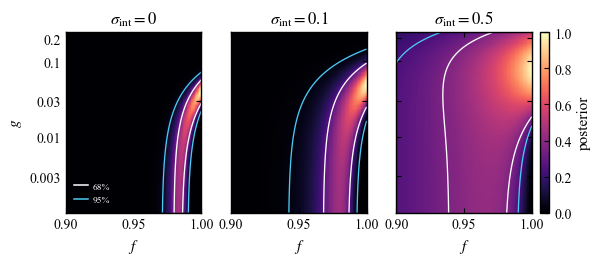

In [5]:
from pathlib import Path
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D
from matplotlib.ticker import NullFormatter, NullLocator

required_previous_names = [
    "residual_and_gradient_fg",
    "gaussian_curve_objective",
    "mcmc_kTe",
    "mcmc_tau",
    "mcmc_sigma_log_kTe",
    "mcmc_sigma_log_tau",
    "finite_difference_step",
    "f_bounds",
    "g_bounds",
    "credible_density_thresholds",
    "output_dir",
    "figure_dir",
    "get_double_column_size",
]
missing_previous_names = [name for name in required_previous_names if name not in globals()]
if missing_previous_names:
    raise RuntimeError(
        "Run the previous f-g posterior cell first; missing: " + ", ".join(missing_previous_names)
    )

scatter_sensitivity_values = (0.0, 0.1, 0.5)
f_axis_sensitivity = np.linspace(f_bounds[0], f_bounds[1], 170)
g_axis_sensitivity = np.geomspace(g_bounds[0], g_bounds[1], 170)


def curve_distance_objective_fg_for_scatter(f_corona, feedback_factor, scatter):
    residual, dR_dlog_kTe, dR_dlog_tau = residual_and_gradient_fg(f_corona, feedback_factor)
    return gaussian_curve_objective(
        residual,
        dR_dlog_kTe,
        dR_dlog_tau,
        mcmc_sigma_log_kTe,
        mcmc_sigma_log_tau,
        scatter,
    )


def log_posterior_fg_for_scatter(f_g, scatter):
    f_corona, feedback_factor = np.asarray(f_g, dtype=float)
    if not (f_bounds[0] <= f_corona <= f_bounds[1]):
        return -math.inf
    if not (g_bounds[0] <= feedback_factor <= g_bounds[1]):
        return -math.inf
    objective_value = curve_distance_objective_fg_for_scatter(
        float(f_corona),
        float(feedback_factor),
        float(scatter),
    )
    if not math.isfinite(objective_value):
        return -math.inf
    return -0.5 * objective_value


def posterior_density_grid_for_scatter(scatter):
    f_mesh, g_mesh = np.meshgrid(f_axis_sensitivity, g_axis_sensitivity)
    logp_grid = np.empty(f_mesh.size, dtype=float)
    for idx, (f_val, g_val) in enumerate(zip(f_mesh.ravel(), g_mesh.ravel())):
        logp_grid[idx] = log_posterior_fg_for_scatter((f_val, g_val), scatter)
    logp_grid = logp_grid.reshape(f_mesh.shape)
    finite = np.isfinite(logp_grid)
    density = np.full_like(logp_grid, np.nan, dtype=float)
    if np.any(finite):
        density[finite] = np.exp(logp_grid[finite] - np.nanmax(logp_grid[finite]))
        density[finite] /= np.nanmax(density[finite])
    return f_mesh, g_mesh, logp_grid, density


def grid_widths(axis, *, log_axis=False):
    axis = np.asarray(axis, dtype=float)
    if log_axis:
        log_axis_values = np.log(axis)
        log_edges = np.empty(axis.size + 1, dtype=float)
        log_edges[1:-1] = 0.5 * (log_axis_values[:-1] + log_axis_values[1:])
        log_edges[0] = log_axis_values[0] - 0.5 * (log_axis_values[1] - log_axis_values[0])
        log_edges[-1] = log_axis_values[-1] + 0.5 * (log_axis_values[-1] - log_axis_values[-2])
        edges = np.exp(log_edges)
    else:
        edges = np.empty(axis.size + 1, dtype=float)
        edges[1:-1] = 0.5 * (axis[:-1] + axis[1:])
        edges[0] = axis[0] - 0.5 * (axis[1] - axis[0])
        edges[-1] = axis[-1] + 0.5 * (axis[-1] - axis[-2])
    return np.diff(edges)


def weighted_quantile(values, weights, probabilities):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    order = np.argsort(values)
    values = values[order]
    weights = weights[order]
    total = np.sum(weights)
    if not np.isfinite(total) or total <= 0.0:
        return np.full(len(probabilities), np.nan, dtype=float)
    cdf = np.cumsum(weights) / total
    return np.interp(probabilities, cdf, values)


f_widths = grid_widths(f_axis_sensitivity)
g_widths = grid_widths(g_axis_sensitivity, log_axis=True)
posterior_cell_weights_sensitivity = g_widths[:, None] * f_widths[None, :]
posterior_density_sensitivity = {}
density_rows = []
summary_rows = []

fig, axes = plt.subplots(
    1,
    len(scatter_sensitivity_values),
    figsize=get_double_column_size(row_height_scale=0.78),
    sharex=True,
    sharey=True,
    gridspec_kw={"wspace": 0.22},
)
contour_color_by_mass = {0.95: "#4cc9f0", 0.68: "#ffffff"}

for ax, scatter in zip(axes, scatter_sensitivity_values, strict=True):
    f_mesh, g_mesh, logp_grid, density = posterior_density_grid_for_scatter(scatter)
    posterior_density_sensitivity[scatter] = density
    weight_grid = np.where(
        np.isfinite(density),
        density * posterior_cell_weights_sensitivity,
        0.0,
    )
    f_marginal = np.sum(weight_grid, axis=0)
    g_marginal = np.sum(weight_grid, axis=1)
    f_q16, f_q50, f_q84 = weighted_quantile(f_axis_sensitivity, f_marginal, [0.16, 0.50, 0.84])
    g_q16, g_q50, g_q84 = weighted_quantile(g_axis_sensitivity, g_marginal, [0.16, 0.50, 0.84])
    summary_rows.extend([
        {
            "intrinsic_log_scatter": scatter,
            "parameter": "f_corona",
            "q16": f_q16,
            "median": f_q50,
            "q84": f_q84,
            "n_clean_compTT": int(mcmc_kTe.size),
            "method": "deterministic_posterior_grid_with_log_sigma",
        },
        {
            "intrinsic_log_scatter": scatter,
            "parameter": "g_feedback",
            "q16": g_q16,
            "median": g_q50,
            "q84": g_q84,
            "n_clean_compTT": int(mcmc_kTe.size),
            "method": "deterministic_posterior_grid_with_log_sigma",
        },
    ])
    for f_val, g_val, logp_val, density_val in zip(f_mesh.ravel(), g_mesh.ravel(), logp_grid.ravel(), density.ravel()):
        density_rows.append({
            "intrinsic_log_scatter": scatter,
            "f_corona": float(f_val),
            "g_feedback": float(g_val),
            "log_posterior": float(logp_val) if math.isfinite(float(logp_val)) else math.nan,
            "posterior_density_relative": float(density_val) if math.isfinite(float(density_val)) else math.nan,
        })

    mesh = ax.pcolormesh(
        f_mesh,
        g_mesh,
        np.ma.masked_invalid(density),
        shading="auto",
        cmap="magma",
        vmin=0.0,
        vmax=1.0,
    )
    credible_contours = credible_density_thresholds(density, (0.95, 0.68), weights=posterior_cell_weights_sensitivity)
    valid_contours = [
        (item["mass"], item["level"], contour_color_by_mass[item["mass"]])
        for item in credible_contours
        if np.nanmin(density) < item["level"] < np.nanmax(density)
    ]
    valid_contours = sorted(valid_contours, key=lambda item: item[1])
    if valid_contours:
        ax.contour(
            f_mesh,
            g_mesh,
            density,
            levels=[item[1] for item in valid_contours],
            colors=[item[2] for item in valid_contours],
            linewidths=0.95,
        )
    ax.set_title(rf"$\sigma_{{\rm int}}={scatter:g}$")
    ax.set_xscale("linear")
    ax.set_yscale("log")
    ax.set_xlim(*f_bounds)
    ax.set_ylim(*g_bounds)
    ax.set_xticks([0.90, 0.95, 1.00])
    ax.set_xticklabels(["0.90", "0.95", "1.00"])
    ax.set_yticks([0.003, 0.01, 0.03, 0.1, 0.2])
    ax.set_yticklabels(["0.003", "0.01", "0.03", "0.1", "0.2"])
    ax.yaxis.set_minor_locator(NullLocator())
    ax.yaxis.set_minor_formatter(NullFormatter())
    ax.set_xlabel(r"$f$")
    ax.grid(False)

axes[0].set_ylabel(r"$g$")
contour_handles = [
    Line2D([], [], color="#ffffff", lw=1.1, label="68%"),
    Line2D([], [], color="#4cc9f0", lw=1.1, label="95%"),
]
legend = axes[0].legend(
    handles=contour_handles,
    frameon=False,
    loc="lower left",
    fontsize=6.8,
    handlelength=1.45,
    handletextpad=0.45,
)
for text in legend.get_texts():
    text.set_color("white")

posterior_cbar = fig.colorbar(ScalarMappable(norm=Normalize(vmin=0.0, vmax=1.0), cmap="magma"), ax=axes, pad=0.015)
posterior_cbar.set_label("posterior")

sensitivity_png = figure_dir / "fg_intrinsic_scatter_sensitivity.png"
sensitivity_pdf = figure_dir / "fg_intrinsic_scatter_sensitivity.pdf"
sensitivity_summary_csv = output_dir / "fg_intrinsic_scatter_sensitivity_summary.csv"
sensitivity_density_csv = output_dir / "fg_intrinsic_scatter_sensitivity_density.csv"
summary_frame = pd.DataFrame(summary_rows)
density_frame = pd.DataFrame(density_rows)
summary_frame.to_csv(sensitivity_summary_csv, index=False)
density_frame.to_csv(sensitivity_density_csv, index=False)
fig.savefig(sensitivity_png, dpi=300, bbox_inches="tight")
fig.savefig(sensitivity_pdf, bbox_inches="tight")
print(f"saved: {sensitivity_png}")
print(f"saved: {sensitivity_pdf}")
print(f"saved: {sensitivity_summary_csv}")
print(f"saved: {sensitivity_density_csv}")
summary_frame


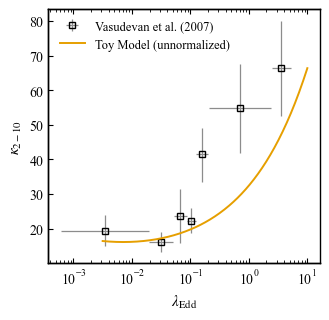

In [6]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from plot_style import apply_mnras_style, get_single_column_size

FIGURE_DIR = Path("figure")
FIGURE_DIR.mkdir(exist_ok=True)

apply_mnras_style()
plt.rcParams["axes.grid"] = False

import mpmath as mp

vasudevan_df = pd.read_csv('data/vasudevan07_calibrated_bined_correction')
vasudevan_df.columns = vasudevan_df.columns.str.strip()
vasudevan_df = vasudevan_df.sort_values('lambda_edd')

lambda_grid = np.logspace(-2.5, 1, 300)
alpha_grid = 0.34 * np.log10(lambda_grid) + 1.34

model_ratio = []
for alpha in alpha_grid:
    s = 1.0 - alpha
    temp = 30.0
    numerator = mp.gammainc(s, 0.1 / temp, 500.0 / temp)
    denominator = mp.gammainc(s, 2.0 / temp, 10.0 / temp)
    model_ratio.append(float(numerator / denominator))
model_ratio = np.asarray(model_ratio)

fig, ax_left = plt.subplots(figsize=get_single_column_size(row_height_scale=1.1))
ax_right = ax_left.twinx()

yerr = np.vstack([
    vasudevan_df['kappa2_10'] - vasudevan_df['low_kappa'],
    vasudevan_df['up_kappa'] - vasudevan_df['kappa2_10'],
])
xerr = np.vstack([
    vasudevan_df['lambda_edd'] - vasudevan_df['low_mdot'],
    vasudevan_df['up_mdot'] - vasudevan_df['lambda_edd'],
])

ax_left.errorbar(
    vasudevan_df['lambda_edd'],
    vasudevan_df['kappa2_10'],
    xerr=xerr,
    yerr=yerr,
    fmt='s',
    markersize=5,
    markerfacecolor='none',
    color='black',
    ecolor='0.55',
    elinewidth=0.9,
    capsize=0,
    linewidth=1.2,
    label='Vasudevan et al. (2007)',
)
ax_right.plot(
    lambda_grid,
    model_ratio,
    color='#E69F00',
    linewidth=1.4,
    label='Toy Model (unnormalized)',
)

ax_left.set_xscale('log')
ax_left.set_xlabel(r'$\lambda_{\rm Edd}$')
ax_left.set_ylabel(r'$\kappa_{2-10}$')
ax_left.grid(False)

left_ylim = ax_left.get_ylim()
data_y_min = vasudevan_df['kappa2_10'].min()
model_y_min = model_ratio.min()
y_scale = data_y_min / model_y_min
ax_right.set_ylim(left_ylim[0] / y_scale, left_ylim[1] / y_scale)

ax_right.tick_params(right=False, labelright=False)
ax_right.spines['right'].set_visible(False)
ax_right.set_ylabel('')

handles_left, labels_left = ax_left.get_legend_handles_labels()
handles_right, labels_right = ax_right.get_legend_handles_labels()
ax_left.legend(handles_left + handles_right, labels_left + labels_right, frameon=False, loc='upper left')

fig.savefig(FIGURE_DIR / 'vasudevan07_vs_toy_model.pdf', dpi=300, bbox_inches='tight')
plt.show()

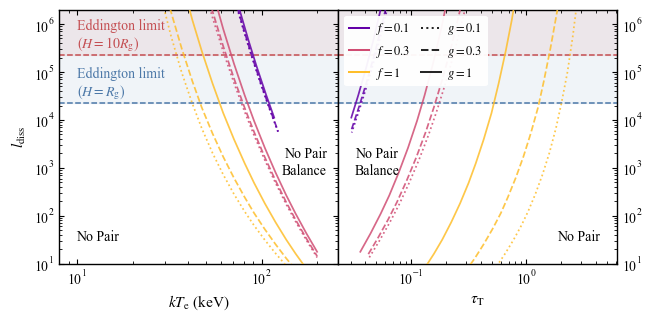

In [7]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from plot_style import apply_mnras_style, get_double_column_size

apply_mnras_style()
plt.rcParams["axes.grid"] = False

FIGURE_DIR = Path("figure")
FIGURE_DIR.mkdir(exist_ok=True)

pair_curve_path = Path("pair_balance/data/comppsc_fg_pair_balance_xi100_f0p1_0p3_1_g0p1_0p3_1_maxsc4000.csv")
pair_df = pd.read_csv(pair_curve_path).sort_values(["f_corona", "g_feedback", "kTe_keV"])
pair_df = pair_df[
    np.isfinite(pair_df["kTe_keV"])
    & np.isfinite(pair_df["tau_T"])
    & np.isfinite(pair_df["l_diss_local"])
    & pair_df["kTe_keV"].gt(0.0)
    & pair_df["tau_T"].gt(0.0)
    & pair_df["l_diss_local"].gt(0.0)
].copy()

f_values = tuple(sorted(pair_df["f_corona"].dropna().unique()))
g_values = tuple(sorted(pair_df["g_feedback"].dropna().unique()))
f_colors = dict(zip(f_values, plt.get_cmap("plasma")(np.linspace(0.18, 0.86, len(f_values)))))
g_linestyles = {0.1: ":", 0.3: "--", 1.0: "-"}
line_specs = [
    (2.3e4, "#4C78A8", r"Eddington limit ($H = R_{\rm g}$)"),
    (2.3e5, "#C44E52", r"Eddington limit ($H = 10R_{\rm g}$)"),
]
ymin, ymax = 10.0, 2.0e6

fig, (ax_left, ax_right) = plt.subplots(
    1,
    2,
    figsize=get_double_column_size(row_height_scale=1.1),
    sharey=True,
    gridspec_kw={"wspace": 0.0},
)

for ax in (ax_left, ax_right):
    for y_value, color, _ in line_specs:
        ax.axhspan(y_value, ymax, color=color, alpha=0.08, zorder=0)

for (f_corona, feedback_factor), sub in pair_df.groupby(["f_corona", "g_feedback"], sort=True):
    color = f_colors[float(f_corona)]
    linestyle = g_linestyles.get(float(feedback_factor), "-")
    ax_left.plot(
        sub["kTe_keV"],
        sub["l_diss_local"],
        color=color,
        linestyle=linestyle,
        linewidth=1.25,
        alpha=0.85,
        zorder=3,
    )
    ax_right.plot(
        sub["tau_T"],
        sub["l_diss_local"],
        color=color,
        linestyle=linestyle,
        linewidth=1.25,
        alpha=0.85,
        zorder=3,
    )

for y_value, color, label in line_specs:
    ax_left.axhline(y_value, color=color, linewidth=1.1, linestyle="--", zorder=2)
    ax_right.axhline(y_value, color=color, linewidth=1.1, linestyle="--", zorder=2)

ax_left.text(10, 2.3e4 * 1.06, "Eddington limit\n" + r"($H = R_{\rm g}$)", color="#4C78A8", ha="left", va="bottom")
ax_left.text(10, 2.3e5 * 1.06, "Eddington limit\n" + r"($H = 10R_{\rm g}$)", color="#C44E52", ha="left", va="bottom")

ax_left.set_xscale("log")
ax_left.set_yscale("log")
ax_left.set_xlabel(r"$kT_{\mathrm{e}}$ (keV)")
ax_left.set_ylabel(r"$l_{\mathrm{diss}}$")
ax_left.set_xlim(8.0, 260.0)
ax_left.set_ylim(ymin, ymax)
ax_left.grid(False)

ax_right.set_xscale("log")
ax_right.set_xlabel(r"$\tau_{\rm T}$")
ax_right.grid(False)
ax_right.yaxis.set_label_position("right")
ax_right.yaxis.tick_right()
ax_right.tick_params(axis="y", which="both", left=False, labelleft=False, right=True, labelright=True)

ax_left.text(0.06, 0.08, "No Pair", transform=ax_left.transAxes, ha="left", va="bottom")
ax_left.text(0.96, 0.4, "No Pair\nBalance", transform=ax_left.transAxes, ha="right", va="center")
ax_right.text(0.94, 0.08, "No Pair", transform=ax_right.transAxes, ha="right", va="bottom")
ax_right.text(0.06, 0.4, "No Pair\nBalance", transform=ax_right.transAxes, ha="left", va="center")

f_handles = [
    Line2D([], [], color=f_colors[f_corona], lw=1.45, label=rf"$f={f_corona:g}$")
    for f_corona in f_values
]
g_handles = [
    Line2D([], [], color="0.15", lw=1.45, linestyle=g_linestyles.get(float(g), "-"), label=rf"$g={g:g}$")
    for g in g_values
]
ax_right.legend(
    handles=f_handles + g_handles,
    frameon=True,
    facecolor="white",
    framealpha=0.95,
    edgecolor="none",
    ncol=2,
    columnspacing=0.9,
    handletextpad=0.5,
    handlelength=1.6,
    loc="upper left",
)

fig.savefig(FIGURE_DIR / "pair_balance.pdf", dpi=300, bbox_inches="tight")
fig.savefig(FIGURE_DIR / "pair_balance.png", dpi=300, bbox_inches="tight")

plt.show()


saved: figure/pair_balance_samples_fg_grid.png
saved: figure/pair_balance_samples_fg_grid.pdf


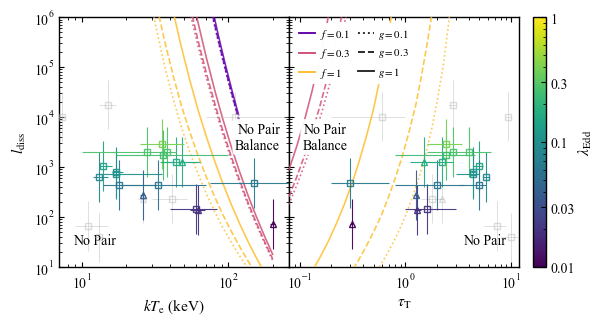

In [8]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D

from plot_style import apply_mnras_style, get_double_column_size

apply_mnras_style()
plt.rcParams["axes.grid"] = False

figure_dir = Path("figure")
figure_dir.mkdir(exist_ok=True)
data_dir = Path("data")

pair_curve_path = Path("pair_balance/data/comppsc_fg_pair_balance_xi100_f0p1_0p3_1_g0p1_0p3_1_maxsc4000.csv")
pair_curves = pd.read_csv(pair_curve_path).sort_values(["f_corona", "g_feedback", "kTe_keV"])
pair_curves = pair_curves[
    np.isfinite(pair_curves["kTe_keV"])
    & np.isfinite(pair_curves["tau_T"])
    & np.isfinite(pair_curves["l_diss_local"])
    & pair_curves["kTe_keV"].gt(0.0)
    & pair_curves["tau_T"].gt(0.0)
    & pair_curves["l_diss_local"].gt(0.0)
].copy()

f_values = tuple(sorted(pair_curves["f_corona"].dropna().unique()))
g_values = tuple(sorted(pair_curves["g_feedback"].dropna().unique()))
f_colors = dict(zip(f_values, plt.get_cmap("plasma")(np.linspace(0.18, 0.86, len(f_values)))))
g_linestyles = {0.1: ":", 0.3: "--", 1.0: "-"}

compactness_prefactor = 2.3e4
f_compactness = 1.0
h_over_rg_values = (1.0, 10.0)
lambda_vmin, lambda_vmax = 0.01, 1.0
lambda_norm = LogNorm(vmin=lambda_vmin, vmax=lambda_vmax)
lambda_cmap = plt.get_cmap("viridis")
marker_map = {"compTT": "s", "compPS": "^"}

compTT = pd.read_csv(data_dir / "compTT_comptt_sample_v2.csv").assign(sample="compTT")
compPS = pd.read_csv(data_dir / "compPS_compps_sample_v2.csv").assign(sample="compPS")
numeric_cols = [
    "Electron_Temperature_keV",
    "Optical_Depth_tau",
    "kTe_Lower_keV",
    "kTe_Upper_keV",
    "tau_Lower",
    "tau_Upper",
    "Eddington_Ratio",
]
for frame in (compTT, compPS):
    frame[numeric_cols] = frame[numeric_cols].apply(pd.to_numeric, errors="coerce")

for col in ["Optical_Depth_tau", "tau_Lower", "tau_Upper"]:
    compTT[col] *= 2.0

samples = pd.concat([compTT, compPS], ignore_index=True)
samples = samples[
    samples["Electron_Temperature_keV"].gt(0.0)
    & samples["Optical_Depth_tau"].gt(0.0)
    & samples["Eddington_Ratio"].gt(0.0)
    & samples["kTe_Lower_keV"].gt(0.0)
    & samples["tau_Lower"].gt(0.0)
].copy().reset_index(drop=True)
samples["force_gray"] = samples["Source"].eq("NGC 5506") | (
    samples["Source"].eq("MCG-5-23-16") & np.isclose(samples["Eddington_Ratio"], 0.032)
)
samples["in_lambda_range"] = samples["Eddington_Ratio"].between(lambda_vmin, lambda_vmax, inclusive="both")
samples["use_lambda_color"] = samples["in_lambda_range"] & ~samples["force_gray"]
samples["sample_ldiss_high"] = (
    compactness_prefactor
    * f_compactness
    * samples["Eddington_Ratio"]
    / min(h_over_rg_values)
)
samples["sample_ldiss_low"] = (
    compactness_prefactor
    * f_compactness
    * samples["Eddington_Ratio"]
    / max(h_over_rg_values)
)
samples["sample_ldiss_mid"] = np.sqrt(samples["sample_ldiss_low"] * samples["sample_ldiss_high"])


def asymmetric_errors(frame, central, lower, upper):
    lower_err = frame[central].to_numpy(dtype=float) - frame[lower].to_numpy(dtype=float)
    upper_err = frame[upper].to_numpy(dtype=float) - frame[central].to_numpy(dtype=float)
    return np.vstack([np.clip(lower_err, 0.0, np.inf), np.clip(upper_err, 0.0, np.inf)])


def draw_sample_compactness(ax, x_key, xerr):
    for _, row in samples.iterrows():
        x_value = float(row[x_key])
        y_low = float(row["sample_ldiss_low"])
        y_high = float(row["sample_ldiss_high"])
        y_mid = float(row["sample_ldiss_mid"])
        if not (np.isfinite(x_value) and np.isfinite(y_low) and np.isfinite(y_high) and y_low > 0.0 and y_high > 0.0):
            continue
        if bool(row["use_lambda_color"]):
            color = lambda_cmap(lambda_norm(float(row["Eddington_Ratio"])))
            alpha = 0.95
            linewidth = 0.8
            zorder = 5
        else:
            color = "0.70"
            alpha = 0.45
            linewidth = 0.65
            zorder = 3
        marker = marker_map.get(row["sample"], "o")
        ax.vlines(x_value, y_low, y_high, color=color, alpha=alpha, linewidth=linewidth, zorder=zorder)
        idx = row.name
        ax.errorbar(
            x_value,
            y_mid,
            xerr=np.asarray(xerr[:, idx:idx + 1], dtype=float),
            fmt=marker,
            markersize=4.3,
            markerfacecolor="none",
            markeredgecolor=color,
            ecolor=color,
            elinewidth=linewidth,
            capsize=0,
            alpha=alpha,
            zorder=zorder + 1,
        )

xerr_kTe = asymmetric_errors(samples, "Electron_Temperature_keV", "kTe_Lower_keV", "kTe_Upper_keV")
xerr_tau = asymmetric_errors(samples, "Optical_Depth_tau", "tau_Lower", "tau_Upper")

ymin, ymax = 10.0, 1.0e6
fig, (ax_kte, ax_tau) = plt.subplots(
    1,
    2,
    figsize=get_double_column_size(row_height_scale=1.08),
    sharey=True,
    gridspec_kw={"wspace": 0.0},
)

for ax in (ax_kte, ax_tau):
    ax.set_yscale("log")
    ax.set_ylim(ymin, ymax)
    ax.grid(False)

for (f_corona, feedback_factor), sub in pair_curves.groupby(["f_corona", "g_feedback"], sort=True):
    color = f_colors[float(f_corona)]
    linestyle = g_linestyles.get(float(feedback_factor), "-")
    ax_kte.plot(
        sub["kTe_keV"],
        sub["l_diss_local"],
        color=color,
        linestyle=linestyle,
        linewidth=1.18,
        alpha=0.84,
        zorder=4,
    )
    ax_tau.plot(
        sub["tau_T"],
        sub["l_diss_local"],
        color=color,
        linestyle=linestyle,
        linewidth=1.18,
        alpha=0.84,
        zorder=4,
    )

draw_sample_compactness(ax_kte, "Electron_Temperature_keV", xerr_kTe)
draw_sample_compactness(ax_tau, "Optical_Depth_tau", xerr_tau)

ax_kte.set_xscale("log")
ax_tau.set_xscale("log")
ax_kte.set_xlim(7.0, 260.0)
ax_tau.set_xlim(0.08, 12.0)
ax_kte.set_xlabel(r"$kT_{\rm e}$ (keV)")
ax_tau.set_xlabel(r"$\tau_{\rm T}$")
ax_kte.set_ylabel(r"$l_{\rm diss}$")
ax_tau.tick_params(axis="y", which="both", left=True, labelleft=False, right=False, labelright=False)

no_pair_balance_bbox = {"boxstyle": "round,pad=0.20", "facecolor": "#ffffff", "edgecolor": "0.72", "linewidth": 0.0, "alpha": 0.94}
ax_kte.text(0.06, 0.08, "No Pair", transform=ax_kte.transAxes, ha="left", va="bottom")
ax_kte.text(0.96, 0.52, "No Pair\nBalance", transform=ax_kte.transAxes, ha="right", va="center", bbox=no_pair_balance_bbox, zorder=20)
ax_tau.text(0.94, 0.08, "No Pair", transform=ax_tau.transAxes, ha="right", va="bottom")
ax_tau.text(0.06, 0.52, "No Pair\nBalance", transform=ax_tau.transAxes, ha="left", va="center", bbox=no_pair_balance_bbox, zorder=20)

f_handles = [
    Line2D([], [], color=f_colors[f_corona], lw=1.35, label=rf"$f={f_corona:g}$")
    for f_corona in f_values
]
g_handles = [
    Line2D([], [], color="0.15", lw=1.35, linestyle=g_linestyles.get(float(g), "-"), label=rf"$g={g:g}$")
    for g in g_values
]
curve_legend = ax_tau.legend(
    handles=f_handles + g_handles,
    frameon=True,
    facecolor="white",
    framealpha=0.88,
    edgecolor="none",
    ncol=2,
    columnspacing=0.75,
    handletextpad=0.45,
    handlelength=1.45,
    loc="upper left",
    fontsize=7.8,
)
ax_tau.add_artist(curve_legend)

cbar = fig.colorbar(ScalarMappable(norm=lambda_norm, cmap=lambda_cmap), ax=[ax_kte, ax_tau], pad=0.025)
cbar.set_label(r"$\lambda_{\rm Edd}$", labelpad=1)
cbar.set_ticks([0.01, 0.03, 0.1, 0.3, 1.0])
cbar.set_ticklabels(["0.01", "0.03", "0.1", "0.3", "1"])

png_path = figure_dir / "pair_balance_samples_fg_grid.png"
pdf_path = figure_dir / "pair_balance_samples_fg_grid.pdf"
fig.savefig(png_path, dpi=300, bbox_inches="tight")
fig.savefig(pdf_path, bbox_inches="tight")
print(f"saved: {png_path}")
print(f"saved: {pdf_path}")
plt.show()


saved: figure/fg_asymmetric_error_posterior_comparison.png
saved: figure/fg_asymmetric_error_posterior_comparison.pdf
saved: output/fg_asymmetric_error_posterior_comparison_summary.csv
saved: output/fg_asymmetric_error_posterior_comparison_density.csv


,intrinsic_log_scatter,error_model,f_q16,f_median,f_q84,g_q16,g_median,g_q84,f_map,g_map,log_posterior_map,n_clean_compTT,method
0,0.00,mean,0.984345,0.992096,0.997723,0.010318,0.026050,0.041751,1.0,0.039974,-11.242212,14,local_curve_distance_split_normal_gaussian_err...
1,0.25,mean,0.942441,0.976010,0.993585,0.027156,0.075790,0.152578,1.0,0.064767,-16.091717,14,local_curve_distance_split_normal_gaussian_err...
2,0.00,asymmetric,0.983755,0.991806,0.997634,0.010493,0.026624,0.043051,1.0,0.036047,-12.262265,14,local_curve_distance_split_normal_gaussian_err...
3,0.25,asymmetric,0.943832,0.976778,0.993791,0.026171,0.072734,0.147840,1.0,0.069390,-16.547514,14,local_curve_distance_split_normal_gaussian_err...


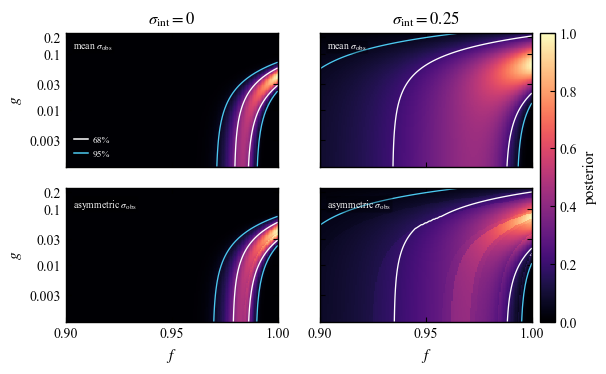

In [9]:
from pathlib import Path
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D
from matplotlib.ticker import NullFormatter, NullLocator

from plot_style import apply_mnras_style, get_double_column_size

apply_mnras_style()
plt.rcParams["axes.grid"] = False

required_previous_names = [
    "residual_and_gradient_fg",
    "mcmc_frame",
    "mcmc_kTe",
    "mcmc_tau",
    "finite_difference_step",
    "f_bounds",
    "g_bounds",
    "credible_density_thresholds",
    "output_dir",
    "figure_dir",
]
missing_previous_names = [name for name in required_previous_names if name not in globals()]
if missing_previous_names:
    raise RuntimeError(
        "Run the previous f-g posterior cell first; missing: " + ", ".join(missing_previous_names)
    )

error_scatter_values = (0.0, 0.25)
error_model_values = ("mean", "asymmetric")
error_model_labels = {
    "mean": r"mean $\sigma_{\rm obs}$",
    "asymmetric": r"asymmetric $\sigma_{\rm obs}$",
}
f_axis_error_test = np.linspace(f_bounds[0], f_bounds[1], 160)
g_axis_error_test = np.geomspace(g_bounds[0], g_bounds[1], 160)


def log_observation_error_components(frame):
    sigma_log_kTe_minus = np.log(frame["Electron_Temperature_keV"].to_numpy(dtype=float) / frame["kTe_Lower_keV"].to_numpy(dtype=float))
    sigma_log_kTe_plus = np.log(frame["kTe_Upper_keV"].to_numpy(dtype=float) / frame["Electron_Temperature_keV"].to_numpy(dtype=float))
    sigma_log_tau_minus = np.log(frame["Optical_Depth_tau"].to_numpy(dtype=float) / frame["tau_Lower"].to_numpy(dtype=float))
    sigma_log_tau_plus = np.log(frame["tau_Upper"].to_numpy(dtype=float) / frame["Optical_Depth_tau"].to_numpy(dtype=float))
    components = {
        "kTe_minus": np.maximum(np.clip(sigma_log_kTe_minus, 0.0, np.inf), 1.0e-3),
        "kTe_plus": np.maximum(np.clip(sigma_log_kTe_plus, 0.0, np.inf), 1.0e-3),
        "tau_minus": np.maximum(np.clip(sigma_log_tau_minus, 0.0, np.inf), 1.0e-3),
        "tau_plus": np.maximum(np.clip(sigma_log_tau_plus, 0.0, np.inf), 1.0e-3),
    }
    components["kTe_mean"] = 0.5 * (components["kTe_minus"] + components["kTe_plus"])
    components["tau_mean"] = 0.5 * (components["tau_minus"] + components["tau_plus"])
    return components


error_components = log_observation_error_components(mcmc_frame)



def projected_sigma_components(residual, dR_dlog_kTe, dR_dlog_tau, scatter, error_model):
    scatter = float(scatter)
    if error_model == "mean":
        sigma_log_kTe = error_components["kTe_mean"]
        sigma_log_tau = error_components["tau_mean"]
    elif error_model == "asymmetric":
        # Linearized split-normal approximation: use the upper/lower error in the
        # direction from the observed point toward the local zero-residual curve.
        direction_log_kTe = -residual * dR_dlog_kTe
        direction_log_tau = -residual * dR_dlog_tau
        sigma_log_kTe = np.where(
            direction_log_kTe > 0.0,
            error_components["kTe_plus"],
            np.where(direction_log_kTe < 0.0, error_components["kTe_minus"], error_components["kTe_mean"]),
        )
        sigma_log_tau = np.where(
            direction_log_tau > 0.0,
            error_components["tau_plus"],
            np.where(direction_log_tau < 0.0, error_components["tau_minus"], error_components["tau_mean"]),
        )
    else:
        raise ValueError(f"Unknown error model: {error_model}")
    sigma_eff_log_kTe = np.sqrt(sigma_log_kTe**2 + scatter**2)
    sigma_eff_log_tau = np.sqrt(sigma_log_tau**2 + scatter**2)
    return sigma_eff_log_kTe, sigma_eff_log_tau


def curve_distance_objective_fg_for_error_model(f_corona, feedback_factor, scatter, error_model):
    residual, dR_dlog_kTe, dR_dlog_tau = residual_and_gradient_fg(f_corona, feedback_factor)
    sigma_eff_log_kTe, sigma_eff_log_tau = projected_sigma_components(
        residual,
        dR_dlog_kTe,
        dR_dlog_tau,
        scatter,
        error_model,
    )
    sigma_R2 = (dR_dlog_kTe * sigma_eff_log_kTe)**2 + (dR_dlog_tau * sigma_eff_log_tau)**2
    valid = np.isfinite(residual) & np.isfinite(sigma_R2) & (sigma_R2 > 0.0)
    if np.count_nonzero(valid) != mcmc_kTe.size:
        return math.inf
    return float(np.sum(residual[valid]**2 / sigma_R2[valid] + np.log(sigma_R2[valid])))


def log_posterior_fg_for_error_model(f_g, scatter, error_model):
    f_corona, feedback_factor = np.asarray(f_g, dtype=float)
    if not (f_bounds[0] <= f_corona <= f_bounds[1]):
        return -math.inf
    if not (g_bounds[0] <= feedback_factor <= g_bounds[1]):
        return -math.inf
    objective_value = curve_distance_objective_fg_for_error_model(
        float(f_corona),
        float(feedback_factor),
        float(scatter),
        error_model,
    )
    if not math.isfinite(objective_value):
        return -math.inf
    return -0.5 * objective_value


def posterior_density_grid_for_error_model(scatter, error_model):
    f_mesh, g_mesh = np.meshgrid(f_axis_error_test, g_axis_error_test)
    logp_grid = np.empty(f_mesh.size, dtype=float)
    for idx, (f_val, g_val) in enumerate(zip(f_mesh.ravel(), g_mesh.ravel())):
        logp_grid[idx] = log_posterior_fg_for_error_model((f_val, g_val), scatter, error_model)
    logp_grid = logp_grid.reshape(f_mesh.shape)
    finite = np.isfinite(logp_grid)
    density = np.full_like(logp_grid, np.nan, dtype=float)
    if np.any(finite):
        density[finite] = np.exp(logp_grid[finite] - np.nanmax(logp_grid[finite]))
        density[finite] /= np.nanmax(density[finite])
    return f_mesh, g_mesh, logp_grid, density


def grid_widths_for_error_test(axis, *, log_axis=False):
    axis = np.asarray(axis, dtype=float)
    if log_axis:
        log_axis_values = np.log(axis)
        log_edges = np.empty(axis.size + 1, dtype=float)
        log_edges[1:-1] = 0.5 * (log_axis_values[:-1] + log_axis_values[1:])
        log_edges[0] = log_axis_values[0] - 0.5 * (log_axis_values[1] - log_axis_values[0])
        log_edges[-1] = log_axis_values[-1] + 0.5 * (log_axis_values[-1] - log_axis_values[-2])
        edges = np.exp(log_edges)
    else:
        edges = np.empty(axis.size + 1, dtype=float)
        edges[1:-1] = 0.5 * (axis[:-1] + axis[1:])
        edges[0] = axis[0] - 0.5 * (axis[1] - axis[0])
        edges[-1] = axis[-1] + 0.5 * (axis[-1] - axis[-2])
    return np.diff(edges)


def weighted_quantile_for_error_test(values, weights, probabilities):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    order = np.argsort(values)
    values = values[order]
    weights = weights[order]
    total = np.sum(weights)
    if not np.isfinite(total) or total <= 0.0:
        return np.full(len(probabilities), np.nan, dtype=float)
    cdf = np.cumsum(weights) / total
    return np.interp(probabilities, cdf, values)


f_widths_error_test = grid_widths_for_error_test(f_axis_error_test)
g_widths_error_test = grid_widths_for_error_test(g_axis_error_test, log_axis=True)
posterior_cell_weights_error_test = g_widths_error_test[:, None] * f_widths_error_test[None, :]
posterior_density_error_test = {}
density_rows = []
summary_rows = []

fig, axes = plt.subplots(
    len(error_model_values),
    len(error_scatter_values),
    figsize=get_double_column_size(row_height_scale=1.25),
    sharex=True,
    sharey=True,
    gridspec_kw={"wspace": 0.20, "hspace": 0.16},
)
contour_color_by_mass = {0.95: "#4cc9f0", 0.68: "#ffffff"}

for row_index, error_model in enumerate(error_model_values):
    for col_index, scatter in enumerate(error_scatter_values):
        ax = axes[row_index, col_index]
        f_mesh, g_mesh, logp_grid, density = posterior_density_grid_for_error_model(scatter, error_model)
        posterior_density_error_test[(error_model, scatter)] = density
        weight_grid = np.where(
            np.isfinite(density),
            density * posterior_cell_weights_error_test,
            0.0,
        )
        f_marginal = np.sum(weight_grid, axis=0)
        g_marginal = np.sum(weight_grid, axis=1)
        f_q16, f_q50, f_q84 = weighted_quantile_for_error_test(f_axis_error_test, f_marginal, [0.16, 0.50, 0.84])
        g_q16, g_q50, g_q84 = weighted_quantile_for_error_test(g_axis_error_test, g_marginal, [0.16, 0.50, 0.84])
        if np.any(np.isfinite(logp_grid)):
            map_index = np.unravel_index(np.nanargmax(logp_grid), logp_grid.shape)
            f_map = float(f_mesh[map_index])
            g_map = float(g_mesh[map_index])
            logp_map = float(logp_grid[map_index])
        else:
            f_map = g_map = logp_map = math.nan
        summary_rows.append({
            "intrinsic_log_scatter": float(scatter),
            "error_model": error_model,
            "f_q16": f_q16,
            "f_median": f_q50,
            "f_q84": f_q84,
            "g_q16": g_q16,
            "g_median": g_q50,
            "g_q84": g_q84,
            "f_map": f_map,
            "g_map": g_map,
            "log_posterior_map": logp_map,
            "n_clean_compTT": int(mcmc_kTe.size),
            "method": "local_curve_distance_split_normal_gaussian_error_test",
        })
        for f_val, g_val, logp_val, density_val in zip(f_mesh.ravel(), g_mesh.ravel(), logp_grid.ravel(), density.ravel()):
            density_rows.append({
                "intrinsic_log_scatter": float(scatter),
                "error_model": error_model,
                "f_corona": float(f_val),
                "g_feedback": float(g_val),
                "log_posterior": float(logp_val) if math.isfinite(float(logp_val)) else math.nan,
                "posterior_density_relative": float(density_val) if math.isfinite(float(density_val)) else math.nan,
            })

        mesh = ax.pcolormesh(
            f_mesh,
            g_mesh,
            np.ma.masked_invalid(density),
            shading="auto",
            cmap="magma",
            vmin=0.0,
            vmax=1.0,
        )
        credible_contours = credible_density_thresholds(density, (0.95, 0.68), weights=posterior_cell_weights_error_test)
        valid_contours = [
            (item["mass"], item["level"], contour_color_by_mass[item["mass"]])
            for item in credible_contours
            if np.nanmin(density) < item["level"] < np.nanmax(density)
        ]
        valid_contours = sorted(valid_contours, key=lambda item: item[1])
        if valid_contours:
            ax.contour(
                f_mesh,
                g_mesh,
                density,
                levels=[item[1] for item in valid_contours],
                colors=[item[2] for item in valid_contours],
                linewidths=0.95,
            )
        if row_index == 0:
            ax.set_title(rf"$\sigma_{{\rm int}}={scatter:g}$")
        ax.text(
            0.035,
            0.93,
            error_model_labels[error_model],
            transform=ax.transAxes,
            color="white",
            fontsize=7.0,
            ha="left",
            va="top",
            bbox={"boxstyle": "round,pad=0.13", "facecolor": "black", "edgecolor": "none", "alpha": 0.25},
        )
        ax.set_xscale("linear")
        ax.set_yscale("log")
        ax.set_xlim(*f_bounds)
        ax.set_ylim(*g_bounds)
        ax.set_xticks([0.90, 0.95, 1.00])
        ax.set_xticklabels(["0.90", "0.95", "1.00"])
        ax.set_yticks([0.003, 0.01, 0.03, 0.1, 0.2])
        ax.set_yticklabels(["0.003", "0.01", "0.03", "0.1", "0.2"])
        ax.yaxis.set_minor_locator(NullLocator())
        ax.yaxis.set_minor_formatter(NullFormatter())
        ax.grid(False)
        if row_index == len(error_model_values) - 1:
            ax.set_xlabel(r"$f$")
        if col_index == 0:
            ax.set_ylabel(r"$g$")

contour_handles = [
    Line2D([], [], color="#ffffff", lw=1.1, label="68%"),
    Line2D([], [], color="#4cc9f0", lw=1.1, label="95%"),
]
legend = axes[0, 0].legend(
    handles=contour_handles,
    frameon=False,
    loc="lower left",
    fontsize=6.8,
    handlelength=1.45,
    handletextpad=0.45,
)
for text in legend.get_texts():
    text.set_color("white")

posterior_cbar = fig.colorbar(ScalarMappable(norm=Normalize(vmin=0.0, vmax=1.0), cmap="magma"), ax=axes, pad=0.015)
posterior_cbar.set_label("posterior")

error_test_png = figure_dir / "fg_asymmetric_error_posterior_comparison.png"
error_test_pdf = figure_dir / "fg_asymmetric_error_posterior_comparison.pdf"
error_test_summary_csv = output_dir / "fg_asymmetric_error_posterior_comparison_summary.csv"
error_test_density_csv = output_dir / "fg_asymmetric_error_posterior_comparison_density.csv"
summary_frame = pd.DataFrame(summary_rows)
density_frame = pd.DataFrame(density_rows)
summary_frame.to_csv(error_test_summary_csv, index=False)
density_frame.to_csv(error_test_density_csv, index=False)
fig.savefig(error_test_png, dpi=300, bbox_inches="tight")
fig.savefig(error_test_pdf, bbox_inches="tight")
print(f"saved: {error_test_png}")
print(f"saved: {error_test_pdf}")
print(f"saved: {error_test_summary_csv}")
print(f"saved: {error_test_density_csv}")
summary_frame


In [10]:
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.special import kve
from scipy.stats import spearmanr


data_dir = Path("data")
output_dir = Path("output")
output_dir.mkdir(exist_ok=True)

MEC2_KEV = 511.0
lambda_vmin, lambda_vmax = 0.01, 1.0


def bessel_factor(theta):
    theta = np.asarray(theta, dtype=float)
    x = 1.0 / theta
    return 4.0 * theta * kve(3, x) / kve(2, x)


def load_compTT_correlation_sample():
    frame = pd.read_csv(data_dir / "compTT_comptt_sample_v2.csv").copy()
    numeric_cols = [
        "Electron_Temperature_keV",
        "Optical_Depth_tau",
        "kTe_Lower_keV",
        "kTe_Upper_keV",
        "tau_Lower",
        "tau_Upper",
        "Eddington_Ratio",
    ]
    frame[numeric_cols] = frame[numeric_cols].apply(pd.to_numeric, errors="coerce")

    # Convert compTT slab half-depth to the full slab optical depth used elsewhere in the paper.
    for col in ["Optical_Depth_tau", "tau_Lower", "tau_Upper"]:
        frame[col] *= 2.0

    frame["force_gray"] = frame["Source"].eq("NGC 5506")
    frame["in_lambda_range"] = frame["Eddington_Ratio"].between(
        lambda_vmin, lambda_vmax, inclusive="both"
    )
    frame["use_clean_sample"] = frame["in_lambda_range"] & ~frame["force_gray"]

    theta = frame["Electron_Temperature_keV"].to_numpy(dtype=float) / MEC2_KEV
    tau = frame["Optical_Depth_tau"].to_numpy(dtype=float)
    frame["y_bessel"] = bessel_factor(theta) * tau

    finite_positive = (
        np.isfinite(frame["Electron_Temperature_keV"])
        & np.isfinite(frame["Eddington_Ratio"])
        & np.isfinite(frame["y_bessel"])
        & frame["Electron_Temperature_keV"].gt(0.0)
        & frame["Optical_Depth_tau"].gt(0.0)
        & frame["Eddington_Ratio"].gt(0.0)
        & frame["y_bessel"].gt(0.0)
    )
    return frame.loc[finite_positive].copy()


def spearman_row(frame, sample_label, variable_label, variable_column):
    sub = frame[[variable_column, "Eddington_Ratio"]].dropna()
    if len(sub) < 3:
        rho, p_value = np.nan, np.nan
    else:
        rho, p_value = spearmanr(sub[variable_column], sub["Eddington_Ratio"])
    return {
        "sample": sample_label,
        "x_quantity": variable_label,
        "y_quantity": "lambda_Edd",
        "n": int(len(sub)),
        "spearman_rho": float(rho),
        "p_value": float(p_value),
    }


compTT_corr = load_compTT_correlation_sample()
correlation_rows = []
for sample_label, sample_frame in [
    ("cleaned compTT", compTT_corr.loc[compTT_corr["use_clean_sample"]].copy()),
    ("full compTT", compTT_corr.copy()),
]:
    correlation_rows.append(
        spearman_row(sample_frame, sample_label, "kTe_keV", "Electron_Temperature_keV")
    )
    correlation_rows.append(
        spearman_row(sample_frame, sample_label, "y_bessel", "y_bessel")
    )

spearman_table = pd.DataFrame(correlation_rows)
spearman_csv = output_dir / "compTT_spearman_correlations.csv"
spearman_table.to_csv(spearman_csv, index=False)
print(f"saved: {spearman_csv}")
spearman_table


saved: output/compTT_spearman_correlations.csv


,sample,x_quantity,y_quantity,n,spearman_rho,p_value
0,cleaned compTT,kTe_keV,lambda_Edd,14,-0.145535,0.619592
1,cleaned compTT,y_bessel,lambda_Edd,14,0.359427,0.206888
2,full compTT,kTe_keV,lambda_Edd,20,-0.027119,0.909642
3,full compTT,y_bessel,lambda_Edd,20,-0.155874,0.511675
